# San Francisco Housing Inventory: Data Cleaning and Exploratory Analysis

Import the analysis libraries and load the housing inventory CSV into `df`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/pragyaapurva/Documents/SJSU/DATA 230/group_project/Rent_Board_Housing_Inventory_20261004.csv')
df.head()

,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,...,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,-9116347526523115483,0285,70.0,Housing Inventory - Unit information (2025),2025,400 Block of STOCKTON ST,Vacant,NaN,NaN,Studio,...,Yes,2024/03/14,2025/02/21,"[\n {\n ""date_range_type"": ""Vacant"",\n ...",1911.0,POINT (-122.408928384 37.798793964),Chinatown,3.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
1,-9115507246175361233,1804,28.0,Housing Inventory - Unit information (2026),2026,1300 Block of LA PLAYA ST,Occupied by non-owner,2024/03/01,2024,One-Bedroom,...,NaN,NaN,2025/11/26,NaN,1958.0,POINT (-122.50914512 37.75935381),Sunset/Parkside,4.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
2,-9112923499523104545,3180,173.0,Housing Inventory - Unit information (2025),2025,300 Block of BRIGHTON AVE,Occupied by non-owner,2023/10/17,2023,Two-Bedroom,...,Yes,NaN,2025/02/23,"[\n {\n ""date_range_type"": ""Occupied"",\n ...",2012.0,POINT (-122.455184003 37.719136184),Oceanview/Merced/Ingleside,11.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
3,-9025339835435158907,8720,1.0,Housing Inventory - Unit information (2026),2026,400 Block of MISSION BAY BLVD,Occupied by non-owner,2023/11/20,2023,Two-Bedroom,...,Yes,NaN,2025/12/08,"[\n {\n ""date_range_type"": ""Occupied"",\n ...",2012.0,POINT (-122.398554627 37.769625656),Mission Bay,6.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
4,-8986949444715099376,0931,1.0,Housing Inventory - Unit information (2024),2024,NaN,Occupied by owner,NaN,NaN,NaN,...,NaN,NaN,2023/11/02,NaN,NaN,POINT (-122.442816487 37.792266218),Pacific Heights,2.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM


# Data Assessment

## Quality Issues

1. **`unit_count`** — unit counts are displayed as floating-point values and should be reviewed for conversion to an integer datatype.  
   **Category:** Datatype

2. **`bedroom_count`** — Equivalent bedroom counts use different representations, such as `One-Bedroom` and `1`.  
   **Category:** Consistency

3. **`bathroom_count`** — Equivalent bathroom counts use different representations, such as `One Bathroom` and `1`.  
   **Category:** Consistency

4. **`square_footage`** — Values contain the unit label `Sq.Ft`, which needs to be handled when extracting numerical values.  
   **Category:** Validity

5. **`monthly_rent`** — Values contain the currency symbol `$`, which needs to be handled when extracting numerical values.  
   **Category:** Validity

6. **`monthly_rent`** — Zero rent is represented inconsistently, with values such as `0` and `$0`.  
   **Category:** Consistency

7. **`occupancy_or_vacancy_date_history`** — Some historical entries are missing `date_range_type`, `start_date`, or `end_date`.  
   **Category:** Completeness

8. **`square_footage`** — Equivalent ranges use inconsistent capitalization, such as `0-250 Sq.Ft` and `0-250 Sq.ft`.  
   **Category:** Consistency

9. **`block_num`** — Contains **2 missing values**.  
   **Category:** Completeness

10. **`unit_count`** — Contains **2 missing values**.  
    **Category:** Completeness

11. **`block_address`** — Contains **78 missing values**.  
    **Category:** Completeness

12. **`occupancy_or_vacancy_date`** — Contains **103,235 missing values**.  
    **Category:** Completeness

13. **`occupancy_or_vacancy_date_year`** — Contains **69,776 missing values**.  
    **Category:** Completeness

14. **`bedroom_count`** — Contains **30,544 missing values**.  
    **Category:** Completeness

15. **`bathroom_count`** — Contains **30,450 missing values**.  
    **Category:** Completeness

16. **`square_footage`** — Contains **585 missing values**.  
    **Category:** Completeness

17. **`monthly_rent`** — Contains **66,509 missing values**.  
    **Category:** Completeness

18. **`base_rent_includes_other_utilities`** — Contains **512,939 missing values**.  
    **Category:** Completeness

19. **`past_occupancy`** — Contains **153,244 missing values**.  
    **Category:** Completeness

20. **`vacancy_date`** — Contains **530,337 missing values**.  
    **Category:** Completeness

21. **`occupancy_or_vacancy_date_history`** — Contains **470,466 missing values**.  
    **Category:** Completeness

22. **`year_property_built`** — Contains **16,002 missing values**.  
    **Category:** Completeness

23. **`analysis_neighborhood`** — Contains **16 missing values**.  
    **Category:** Completeness

24. **`supervisor_district`** — Contains **13 missing values**.  
    **Category:** Completeness

25. **`occupancy_or_vacancy_date_year`** — Contains implausible year values, such as `5020` and `20205`, that require investigation. Valid year values should be converted to an integer datatype.  
    **Category:** Accuracy

26. **`occupancy_or_vacancy_date`** — Date values are stored as strings and should be converted to datetime.  
    **Category:** Datatype

27. **`data_as_of`** and **`data_loaded_at`** — Timestamp values are stored as strings and should be converted to datetime.  
    **Category:** Datatype

28. **`square_footage`** and **`monthly_rent`** — If lower and upper bounds are extracted, those bounds should use appropriate numerical datatypes.  
    **Category:** Datatype

29. **`bedroom_count`** and **`bathroom_count`** — Labels and special categories need to be interpreted and standardized before deriving numerical counts.  
    **Category:** Datatype

30. **`vacancy_date`** and **`signature_date`** — Date values are stored as strings and should be converted to datetime.  
    **Category:** Datatype

30. **`date_comparison`** — Created to indicate whether the reported occupancy or vacancy date occurred before, after, or on the signature date. Rows with missing or unparseable dates, or years outside the accepted range of 1800–2026, are labeled "Cannot compare".  
    **Category:** Feature Engineering

## Tidiness Issues and Structural Transformations

1. **`square_footage`** — Optionally split each range into separate **lower-bound** and **upper-bound** columns.

2. **`monthly_rent`** — Optionally split each range into separate **lower-bound** and **upper-bound** columns.

3. **`occupancy_or_vacancy_date_history`** — Expand the history into **one row per historical period**, with separate columns for **start date**, **end date**, and **occupancy/vacancy status**, while retaining a link to the original submission record.

4. **`point`** — Extract separate **longitude** and **latitude** columns and store each coordinate as a floating-point value.



In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551551 entries, 0 to 551550
Data columns (total 28 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   unique_id                            551551 non-null  int64  
 1   block_num                            551549 non-null  str    
 2   unit_count                           551549 non-null  float64
 3   case_type_name                       551551 non-null  str    
 4   submission_year                      551551 non-null  int64  
 5   block_address                        551473 non-null  str    
 6   occupancy_type                       551551 non-null  str    
 7   occupancy_or_vacancy_date            448316 non-null  str    
 8   occupancy_or_vacancy_date_year       481775 non-null  str    
 9   bedroom_count                        521007 non-null  str    
 10  bathroom_count                       521101 non-null  str    
 11  square_footage          

### Assess Missing Values

Count missing values in each column and calculate their percentages. The following chart shows which columns have the most missing data.


In [4]:
no_of_null = df.isnull().sum().reset_index()
no_of_null.rename(columns = {0:'no_of_null_vals', 'index': 'column_name'}, inplace = True) 
no_of_null['pct'] = no_of_null['no_of_null_vals']/len(df) *100
no_of_null.sort_values(['pct'], ascending = [False] ,inplace = True)
no_of_null

,column_name,no_of_null_vals,pct
19,vacancy_date,530337,96.153756
17,base_rent_includes_other_utilities,512939,92.999378
21,occupancy_or_vacancy_date_history,470466,85.298730
18,past_occupancy,153244,27.784194
7,occupancy_or_vacancy_date,103235,18.717217
8,occupancy_or_vacancy_date_year,69776,12.650870
12,monthly_rent,66509,12.058540
9,bedroom_count,30544,5.537838
10,bathroom_count,30450,5.520795
22,year_property_built,16002,2.901273


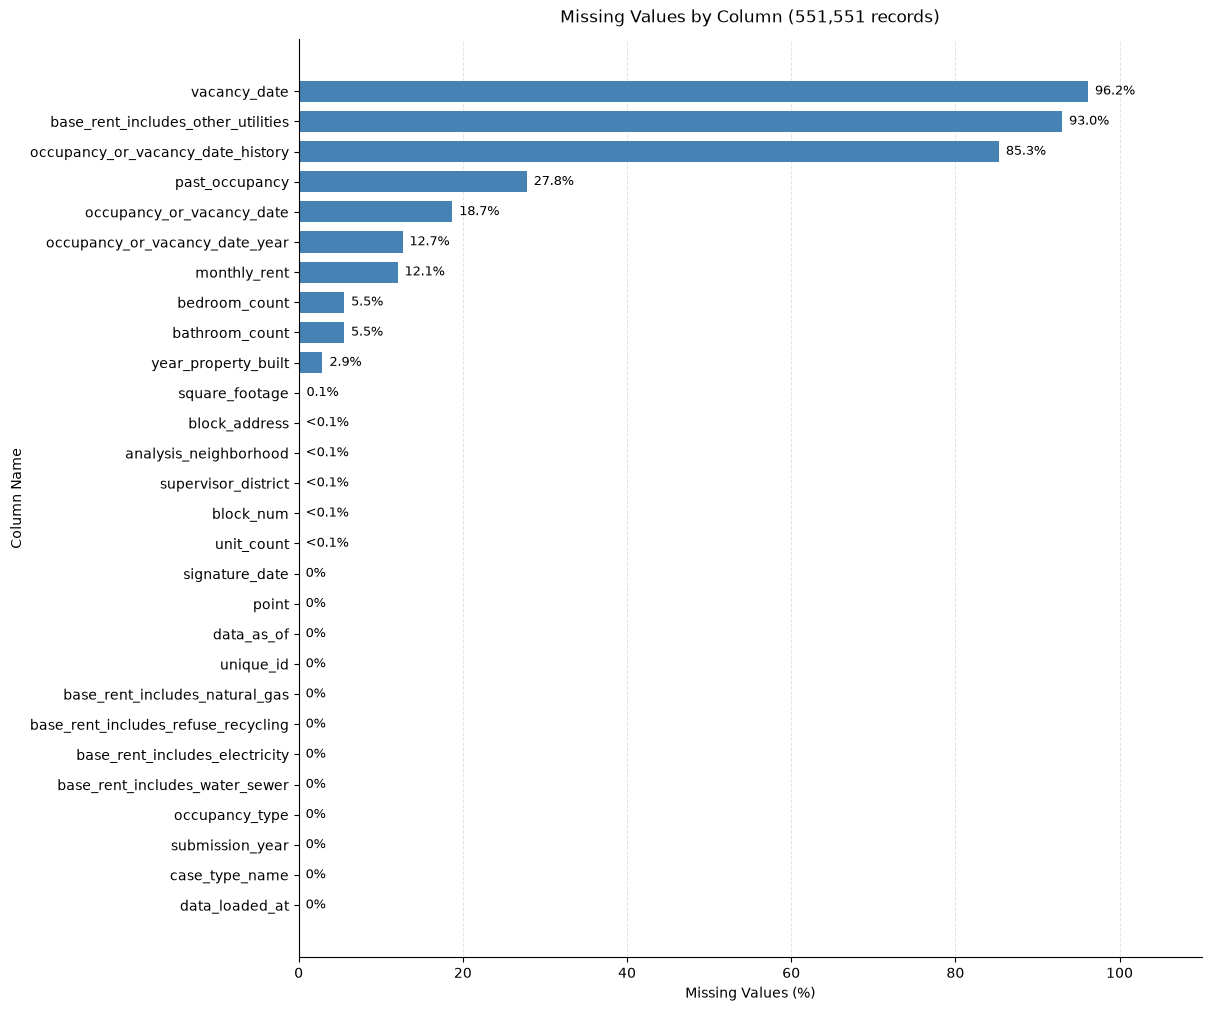

In [5]:
fig, ax = plt.subplots(
    figsize=(12, 10),
    layout='constrained'
)

bars = ax.barh(
    no_of_null['column_name'],
    no_of_null['pct'],
    color='steelblue',
    height=0.7
)

# Highest missing percentage at the top
ax.invert_yaxis()

# Vertical grid lines, behind the bars
ax.set_axisbelow(True)
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.7,
    alpha=0.35
)

# Percentage labels; distinguish tiny percentages from zero
labels = [
    '0%' if pct == 0
    else '<0.1%' if pct < 0.1
    else f'{pct:.1f}%'
    for pct in no_of_null['pct']
]

ax.bar_label(bars, labels=labels, padding=5, fontsize=9)

# Space after the bars for the labels
ax.set_xlim(0, 110)
ax.set_xticks(range(0, 101, 20))

ax.set_xlabel('Missing Values (%)')
ax.set_ylabel('Column Name')
ax.set_title(
    f'Missing Values by Column ({len(df):,} records)',
    pad=12
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Review Numerical Summaries

Summarize the numerical columns and inspect records with a unit count of 720.


In [6]:
df.describe()

,unique_id,unit_count,submission_year,year_property_built,supervisor_district
count,5.515510e+05,551549.000000,551551.000000,535549.000000,551538.000000
mean,-8.371009e+15,69.348847,2024.285294,1940.655273,4.861174
std,5.321343e+18,123.232107,1.343361,35.452667,2.639717
min,-9.223315e+18,0.000000,2022.000000,1808.000000,1.000000
25%,-4.609461e+18,6.000000,2023.000000,1911.000000,3.000000
50%,-1.126144e+16,18.000000,2024.000000,1927.000000,5.000000
75%,4.598275e+18,61.000000,2025.000000,1964.000000,7.000000
max,9.223363e+18,720.000000,2026.000000,2025.000000,11.000000


In [7]:
df[df['unit_count']==720]

,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,...,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
372,-9222331840757428083,7282,720.0,Housing Inventory - Unit information (2022),2022,600 Block of JOHN MUIR DR,Occupied by non-owner,NaN,NaN,1,...,No,NaN,2022/06/12,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
409,-9212424276819803364,7282,720.0,Housing Inventory - Unit information (2024),2024,600 Block of JOHN MUIR DR,Occupied by non-owner,2021/12/01,2021,One-Bedroom,...,No,NaN,2024/05/01,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
427,-9208061844919898053,7282,720.0,Housing Inventory - Unit information (2025),2025,500 Block of JOHN MUIR DR,Occupied by non-owner,2021/06/24,2021,One-Bedroom,...,No,NaN,2025/02/26,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
593,-9215190533860875969,7282,720.0,Housing Inventory - Unit information (2022),2022,600 Block of JOHN MUIR DR,Occupied by non-owner,NaN,NaN,1,...,No,NaN,2022/06/15,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
603,-9212047359579423908,7282,720.0,Housing Inventory - Unit information (2022),2022,500 Block of JOHN MUIR DR,Occupied by non-owner,NaN,NaN,1,...,No,NaN,2022/06/15,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550833,-4667040144184200094,7282,720.0,Housing Inventory - Unit information (2022),2022,500 Block of JOHN MUIR DR,Occupied by non-owner,NaN,NaN,2,...,No,NaN,2022/06/15,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
550861,-4659937684463085440,7282,720.0,Housing Inventory - Unit information (2022),2022,600 Block of JOHN MUIR DR,Occupied by non-owner,2021/02/06,2021,2,...,No,NaN,2022/06/30,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
550909,-4645263991682980705,7282,720.0,Housing Inventory - Unit information (2026),2026,500 Block of JOHN MUIR DR,Occupied by non-owner,2009/05/29,2009,Two-Bedroom,...,No,NaN,2026/04/27,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM
551183,-4668775363388460700,7282,720.0,Housing Inventory - Unit information (2024),2024,500 Block of JOHN MUIR DR,Vacant,NaN,NaN,Studio,...,No,NaN,2024/04/24,NaN,1973.0,POINT (-122.492030022 37.714311121),Lakeshore,7.0,2026/10/04 01:31:50 AM,2026/10/04 06:19:55 AM


## Data Cleaning

Create `sf_rent` as a copy of `df` to use for cleaning and creating new columns.


In [8]:
sf_rent = df.copy()

In [9]:
sf_rent['bedroom_count'].value_counts()

bedroom_count
One-Bedroom       209412
Studio            141669
Two-Bedroom       127710
Three-Bedroom      30199
Four-Bedroom        6264
5+                  1615
1                   1569
2                    999
0                    605
One Bedroom          199
3                    163
Two Bedroom          145
studio               143
1 Bedroom             74
1 bedroom             41
1br                   38
3 bedroom             26
One-bedroom           18
2 bedroom             13
2br                   12
2A                    11
Garage                10
2S                     9
1A                     7
Studio (sm)            6
2brd                   6
2U                     5
2T                     5
3bedroom               4
Two-bedroom            4
1U                     4
1bedroom               3
0U                     3
1T                     2
Zero -(Studio)         2
Five-Bedroom           2
Zero-(Studio)          2
Vacant                 1
$D$61                  1
0A         

### Standardize Bedroom Categories

Remove extra spaces and group equivalent bedroom labels into `bedroom_category`, including studio, bedroom-count, and other categories.


In [10]:
bedroom_groups = {
    "Studio": [
        "Studio",
        "studio",
        "0",
        "Studio (sm)",
        "Zero -(Studio)",
        "Zero-(Studio)"
    ],

    "1 Bedroom": [
        "One-Bedroom",
        "One-bedroom",
        "One Bedroom",
        "1",
        "1 Bedroom",
        "1 bedroom",
        "1br",
        "1bedroom",
        "1 bed"
    ],

    "2 Bedrooms": [
        "Two-Bedroom",
        "Two-bedroom",
        "Two Bedroom",
        "2",
        "2 bedroom",
        "2br",
        "2brd",
        "2 bedroomq",
        "2 bedriin"
    ],

    "3 Bedrooms": [
        "Three-Bedroom",
        "3",
        "3 bedroom",
        "3bedroom"
    ],

    "4 Bedrooms": [
        "Four-Bedroom"
    ],

    "5 Bedrooms": [
        "Five-Bedroom"
    ],

    "5+ Bedrooms": [
        "5+"
    ],
    "Others": [
    "2A",
    "Garage",
    "2S",
    "1A",
    "2U",
    "2T",
    "1U",
    "0U",
    "1T",
    "Vacant",
    "$D$61",
    "0A",
    "2AH",
    "0AH"
    ]
}
sf_rent["bedroom_count"] = sf_rent["bedroom_count"].str.strip().str.replace(r"\s+", " ", regex=True)

sf_rent["bedroom_category"] = sf_rent["bedroom_count"].copy()

for category, labels in bedroom_groups.items():
    mask = sf_rent["bedroom_count"].isin(labels)
    sf_rent.loc[mask, 'bedroom_category'] = category

sf_rent[['bedroom_category', 'bedroom_count']]

,bedroom_category,bedroom_count
0,Studio,Studio
1,1 Bedroom,One-Bedroom
2,2 Bedrooms,Two-Bedroom
3,2 Bedrooms,Two-Bedroom
4,NaN,NaN
...,...,...
551546,1 Bedroom,One-Bedroom
551547,2 Bedrooms,Two-Bedroom
551548,Studio,Studio
551549,Studio,Studio


In [11]:
sf_rent['bedroom_category'].unique()

<ArrowStringArray>
[     'Studio',   '1 Bedroom',  '2 Bedrooms',           nan,  '3 Bedrooms',
  '4 Bedrooms', '5+ Bedrooms',      'Others',  '5 Bedrooms']
Length: 9, dtype: str

In [12]:
sf_rent['bathroom_count'].value_counts()

bathroom_count
One bathroom                                   416051
Two bathrooms                                   60498
Shared bathroom facilities with other units     21037
One and a half bathrooms                        10898
Three bathrooms or more                          4689
Two and a half bathrooms                         3912
1                                                2617
One Bathroom                                      529
2                                                 240
One-Bathroom                                      130
Two bathroom                                      124
0                                                  93
1.00                                               65
1 bathroom                                         64
2 bathroom                                         52
2.5                                                52
One-Bedroom                                        12
2.00                                                6
Two-Bathroom 

### Standardize Bathroom Categories

Remove extra spaces and group equivalent bathroom labels into `bathroom_category`. Keep categories for half bathrooms and shared bathroom facilities.


In [13]:
bathroom_groups = {
    "0 Bathrooms": [
        "0"
    ],

    "1 Bathroom": [
        "One bathroom",
        "One Bathroom",
        "One-Bathroom",
        "1",
        "1.00",
        "1 bathroom",
        "1bathroom"
    ],

    "1.5 Bathrooms": [
        "One and a half bathrooms",
        "One and a Half Bathrooms",
        "One and a half bathdrooms"
    ],

    "2 Bathrooms": [
        "Two bathrooms",
        "Two bathroom",
        "Two Bathroom",
        "Two-Bathroom",
        "2",
        "2.00",
        "2 bathroom",
        "2 batroom"
    ],

    "2.5 Bathrooms": [
        "Two and a half bathrooms",
        "2.5"
    ],

    "3.5 Bathrooms": [
        "3.5"
    ],

    "3+ Bathrooms": [
        "Three bathrooms or more"
    ],

    "Shared Bathroom Facilities": [
        "Shared bathroom facilities with other units",
        "shared bathroom facilities with other units"
    ],
    "Others": [
    "One-Bedroom",
    "1 bedroom",
    "2 bedroom",
    "E3"
    ]
}
sf_rent["bathroom_count"] = sf_rent["bathroom_count"].str.strip().str.replace(r"\s+", " ", regex=True)

sf_rent["bathroom_category"] = sf_rent["bathroom_count"].copy()


for category, labels in bathroom_groups.items():
    mask = sf_rent["bathroom_count"].isin(labels)
    sf_rent.loc[mask, 'bathroom_category'] = category

sf_rent[['bathroom_category', 'bathroom_count']]




,bathroom_category,bathroom_count
0,1 Bathroom,One bathroom
1,1 Bathroom,One bathroom
2,2 Bathrooms,Two bathrooms
3,2 Bathrooms,Two bathrooms
4,NaN,NaN
...,...,...
551546,1 Bathroom,One bathroom
551547,2 Bathrooms,Two bathrooms
551548,1 Bathroom,One bathroom
551549,1 Bathroom,One bathroom


### Remove the Original Bedroom and Bathroom Columns

Drop `bedroom_count` and `bathroom_count` after creating the standardized category columns.


In [14]:
# sf_rent['bathroom_category'] = sf_rent['bathroom_category'].replace('Others', np.nan)
# sf_rent['bathroom_category'].unique()

In [15]:
sf_rent.drop(columns=["bedroom_count", "bathroom_count"], inplace=True)

In [16]:
sf_rent['square_footage'].value_counts()

square_footage
501-750 Sq.Ft      167066
751-1000 Sq.Ft     111251
251-500 Sq.Ft      109905
1001-1250 Sq.Ft     51631
Unknown             38428
0-250 Sq.Ft         34662
1251-1500 Sq.Ft     19699
1501-1750 Sq.Ft      9101
1751-2000 Sq.Ft      4069
2001-2250 Sq.Ft      1720
2251-2500 Sq.Ft      1520
2501-2750 Sq.Ft       542
2751-3000 Sq.Ft       537
4000+ Sq.Ft           226
3001-3250 Sq.Ft       225
3251-3500 Sq.Ft       187
3501-3750 Sq.Ft       126
3751-4000 Sq.Ft        70
0-250 Sq.ft             1
Name: count, dtype: int64

### Split Square Footage into Lower and Upper Bounds

Replace `Unknown` with a missing value, remove the `Sq.Ft` label, and split ranges into `lower_bound_square_footage` and `upper_bound_square_footage`. Open-ended values such as `4000+` have no upper bound.


In [17]:
sf_rent['square_footage'] = sf_rent['square_footage'].replace('Unknown', np.nan)
sf_rent['square_footage'] = sf_rent['square_footage'].str.replace("Sq.Ft", "", case=False, regex=False).str.strip()
sf_rent[['lower_bound_square_footage', 'upper_bound_square_footage']] = sf_rent['square_footage'].str.split('-',expand=True)

In [18]:
sf_rent[['lower_bound_square_footage', 'upper_bound_square_footage']] 

,lower_bound_square_footage,upper_bound_square_footage
0,251,500
1,501,750
2,1001,1250
3,1251,1500
4,NaN,NaN
...,...,...
551546,501,750
551547,1251,1500
551548,251,500
551549,501,750


In [19]:
sf_rent['monthly_rent'].value_counts()

monthly_rent
$2251-$2500                          41151
$1751-$2000                          40284
$2751-$3000                          38510
$2501-$2750                          36980
$2001-$2250                          36829
$1501-$1750                          36263
$1251-$1500                          31845
$3001-$3250                          29590
$3251-$3500                          27843
$1001-$1250                          26964
$751-$1000                           18794
$3501-$3750                          18031
$3751-$4000                          17121
$501-$750                            16600
$4001-$4250                          10968
$4251-$4500                          10210
$4751-$5000                           7127
$4501-$4750                           6559
$251-$500                             6063
$7000+                                4053
$5001-$5250                           3985
$5251-$5500                           3624
$0 (no rent paid by the occupant)     358

### Split Monthly Rent into Lower and Upper Bounds

Remove currency symbols and the no-rent description, then split ranges into `lower_bound_monthly_rent` and `upper_bound_monthly_rent`. Open-ended values such as `7000+` have no upper bound.


In [20]:
sf_rent['monthly_rent'] = sf_rent['monthly_rent'].str.replace("$", "", regex=False).str.strip()
sf_rent['monthly_rent'] = sf_rent['monthly_rent'].str.replace("(no rent paid by the occupant)", "" ,regex=False).str.strip()
sf_rent[['lower_bound_monthly_rent', 'upper_bound_monthly_rent']] = sf_rent['monthly_rent'].str.split('-', expand=True)

In [21]:
sf_rent[['lower_bound_monthly_rent', 'upper_bound_monthly_rent']]

,lower_bound_monthly_rent,upper_bound_monthly_rent
0,1501,1750
1,2751,3000
2,3751,4000
3,6251,6500
4,NaN,NaN
...,...,...
551546,2751,3000
551547,4751,5000
551548,1751,2000
551549,1501,1750


In [22]:
sf_rent['occupancy_type'].value_counts()

occupancy_type
Occupied by non-owner    484805
Vacant                    36109
Occupied by owner         28005
Non-Residential            2632
Name: count, dtype: int64

### Extract Longitude and Latitude

Split each `POINT (longitude latitude)` value into separate numerical columns. The first coordinate is longitude and the second is latitude.


In [23]:
# 1. Remove the word POINT and the parentheses
points = sf_rent['point'].str.replace('POINT', '', regex=False)
points = points.str.replace('(', '', regex=False)
points = points.str.replace(')', '', regex=False)

# 2. Separate the two numbers at the space between them
coordinates = points.str.split(expand=True)

# 3. Store each number in its own column
sf_rent['longitude'] = coordinates[0].astype(float)
sf_rent['latitude'] = coordinates[1].astype(float)

# View the result
sf_rent[['point', 'longitude', 'latitude']].head()

,point,longitude,latitude
0,POINT (-122.408928384 37.798793964),-122.408928,37.798794
1,POINT (-122.50914512 37.75935381),-122.509145,37.759354
2,POINT (-122.455184003 37.719136184),-122.455184,37.719136
3,POINT (-122.398554627 37.769625656),-122.398555,37.769626
4,POINT (-122.442816487 37.792266218),-122.442816,37.792266


In [24]:
sf_rent['occupancy_or_vacancy_date_year'].value_counts()

occupancy_or_vacancy_date_year
2021     75228
2023     69377
2022     66537
2024     43297
2020     33926
         ...  
2560         1
2176         1
0124         1
20205        1
5020         1
Name: count, Length: 182, dtype: int64

In [25]:
for i in sf_rent['occupancy_or_vacancy_date_year'].unique():
    print(i)

nan
2024
2023
2025
2021
2010
2008
1994
2022
2015
1981
2012
2020
2003
1999
2002
2017
2013
2014
1991
2018
1988
2019
1995
2011
1992
1993
1976
2009
2007
2001
2005
2016
Year unknown (no information available)
2026
1990
1998
2006
2004
Year Unknown (within past 5-10 years)
1985
1970
1982
Year Unknown (more than 20 years)
1997
1996
2000
1987
1989
1984
0021
Year Unknown (within past five years)
1980
Year Unknown (within past 10-20 years)
1986
1978
1983
1979
1974
1977
1905
20201
1900
06
1971
1959
20
0201
1973
1966
1967
1975
1963
1952
1964
1969
1965
1972
0219
20252
20211
1012
1955
1899
4502
2077
1962
0214
2068
21
2558
2367
0022
1953
1968
1957
0123
0222
0987
84
0202
2340
3984
20222
0206
1985.
2531
1954
1946
0200
20204
20217
2505
18
21994
12023
2504
1950
1022
1902
2612
2503
2028
2035
2027
0205
2559
2065
2285
0197
20220
2029
2586
2533
202023
91
1960
2109
1948
20022
3022
2366
2476
2423
2614
0204
3873
2613
2587
4531
20005
2477
0199
2530
22
2037
3020
202
2585
2069
0003
0121
1961
2120
0211
52022
1904
10

### Clean Occupancy or Vacancy Years

Remove trailing periods and keep integer years from 1800 through 2026. Preserve the `Year Unknown` categories and replace other invalid values with missing values.


In [26]:
sf_rent['occupancy_or_vacancy_date_year'] = sf_rent['occupancy_or_vacancy_date_year'].str.rstrip('.')

# Identify the text categories we want to keep
keep_text = sf_rent['occupancy_or_vacancy_date_year'].str.contains('year unknown', case=False, na=False)

# Temporarily convert values to numbers for checking
year_numbers = pd.to_numeric(sf_rent['occupancy_or_vacancy_date_year'], errors='coerce')

valid_years = np.arange(1800,2027)

mask = ~year_numbers.isin(valid_years) & ~keep_text
sf_rent.loc[mask, 'occupancy_or_vacancy_date_year'] = pd.NA


In [27]:
sf_rent['occupancy_or_vacancy_date_year'].value_counts()

occupancy_or_vacancy_date_year
2021    75228
2023    69377
2022    66537
2024    43297
2020    33926
        ...  
1960        2
1961        2
1950        1
1904        1
1945        1
Name: count, Length: 87, dtype: int64

### Compare Occupancy or Vacancy Dates with Signature Dates

Create `date_comparison` to label dates as `Before signing`, `After signing`, or `On signing date`. Rows excluded by the valid-year mask or with missing or unparseable dates remain `Cannot compare`.


In [28]:
# Create the mask while the year column still contains years
valid_years = np.arange(1800, 2027).astype(str)
mask = sf_rent['occupancy_or_vacancy_date_year'].astype('string').isin(valid_years)

occupancy = pd.to_datetime(
    sf_rent['occupancy_or_vacancy_date'],
    format='%Y/%m/%d', errors='coerce'
)

signature = pd.to_datetime(
    sf_rent['signature_date'],
    format='%Y/%m/%d', errors='coerce'
)

# Store the labels in date_comparison
sf_rent['date_comparison'] = 'Cannot compare'

sf_rent.loc[mask & (occupancy < signature), 'date_comparison'] = 'Before signing'
sf_rent.loc[mask & (occupancy > signature), 'date_comparison'] = 'After signing'
sf_rent.loc[mask & (occupancy == signature), 'date_comparison'] = 'On signing date'

sf_rent['date_comparison'].value_counts()

date_comparison
Before signing     445310
Cannot compare     103421
After signing        2346
On signing date       474
Name: count, dtype: int64

## Data Type Conversions

### Convert Unit Counts and Coordinates

Convert `unit_count` to nullable integers and longitude and latitude to nullable floating-point numbers. These types support missing values.


In [29]:
# Int64 supports whole numbers and missing values
sf_rent['unit_count'] = sf_rent['unit_count'].astype('Int64')

sf_rent['longitude'] = sf_rent['longitude'].astype('Float64')
sf_rent['latitude'] = sf_rent['latitude'].astype('Float64')

### Convert Date Columns to Datetime

Convert occupancy or vacancy dates, vacancy dates, and signature dates from text to datetime. Missing or unparseable values become `NaT`.


In [30]:
date_columns = [
    'occupancy_or_vacancy_date',
    'vacancy_date',
    'signature_date'
]

for col in date_columns:
    sf_rent[col] = pd.to_datetime(sf_rent[col], format='%Y/%m/%d', errors='coerce')

### Convert Data Timestamps to Datetime

Convert `data_as_of` and `data_loaded_at` to datetime using their date, time, and AM/PM format.


In [31]:
for col in ['data_as_of', 'data_loaded_at']:
    sf_rent[col] = pd.to_datetime(sf_rent[col],format='%Y/%m/%d %I:%M:%S %p',errors='coerce')

## Check the Final Data Types

Display the data types in `sf_rent` to review the conversions completed above.


In [32]:
sf_rent.dtypes

unique_id                                       int64
block_num                                         str
unit_count                                      Int64
case_type_name                                    str
submission_year                                 int64
block_address                                     str
occupancy_type                                    str
occupancy_or_vacancy_date              datetime64[us]
occupancy_or_vacancy_date_year                    str
square_footage                                    str
monthly_rent                                      str
base_rent_includes_water_sewer                    str
base_rent_includes_natural_gas                    str
base_rent_includes_electricity                    str
base_rent_includes_refuse_recycling               str
base_rent_includes_other_utilities                str
past_occupancy                                    str
vacancy_date                           datetime64[us]
signature_date              

### Prepare Numeric Features for the Charts

Convert bedroom and bathroom categories with known, exact counts into numbers. A studio is recorded as zero bedrooms. Categories such as 5+ bedrooms, 3+ bathrooms, shared bathrooms, and other labels do not give an exact count, so they are left out of the numeric summaries.

Estimate monthly rent and square footage by averaging their lower and upper bounds. For example, a rent range of $1,501–$1,750 has a midpoint of $1,625.50. A midpoint is an estimate, rather than an exact reported amount. Exact zero rent stays zero. Open-ended ranges such as $7,000+ or 4,000+ square feet have no midpoint and are excluded from the corresponding summaries.

Calculate property age by subtracting the year built from the current calendar year. This gives an approximate age in years because the dataset does not provide the full construction date.


In [33]:
bedroom_numbers = {
    'Studio': 0,
    '1 Bedroom': 1,
    '2 Bedrooms': 2,
    '3 Bedrooms': 3,
    '4 Bedrooms': 4,
    '5 Bedrooms': 5
}

bathroom_numbers = {
    '0 Bathrooms': 0,
    '1 Bathroom': 1,
    '1.5 Bathrooms': 1.5,
    '2 Bathrooms': 2,
    '2.5 Bathrooms': 2.5,
    '3.5 Bathrooms': 3.5
}

sf_rent['bedroom_numeric'] = (
    sf_rent['bedroom_category'].map(bedroom_numbers).astype('Float64')
)

sf_rent['bathroom_numeric'] = (
    sf_rent['bathroom_category'].map(bathroom_numbers).astype('Float64')
)

# Convert the monthly rent bounds to numbers
rent_bounds = ['lower_bound_monthly_rent', 'upper_bound_monthly_rent']

for col in rent_bounds:
    sf_rent[col] = (
        sf_rent[col].astype('string')
        .str.replace(',', '', regex=False)
        .str.replace('+', '', regex=False)
    )
    sf_rent[col] = pd.to_numeric(sf_rent[col], errors='coerce').astype('Float64')

# Zero rent is an exact value, so both bounds are zero
zero_rent = sf_rent['monthly_rent'].astype('string').str.strip().eq('0')
sf_rent.loc[zero_rent, 'upper_bound_monthly_rent'] = 0

# Estimate monthly rent using the midpoint of the two bounds
sf_rent['monthly_rent_midpoint'] = (
    sf_rent['lower_bound_monthly_rent'] + sf_rent['upper_bound_monthly_rent']
) / 2

sf_rent['lower_bound_square_footage'] = pd.to_numeric(
    sf_rent['lower_bound_square_footage']
    .astype('string').str.rstrip('+'),
    errors='coerce'
)

sf_rent['upper_bound_square_footage'] = pd.to_numeric(
    sf_rent['upper_bound_square_footage'],
    errors='coerce'
)

sf_rent['square_footage_midpoint'] = (
    sf_rent['lower_bound_square_footage'] +
    sf_rent['upper_bound_square_footage']
) / 2

sf_rent['property_age'] = pd.Timestamp.today().year - sf_rent['year_property_built']


sf_rent[
    ['monthly_rent', 'lower_bound_monthly_rent',
     'upper_bound_monthly_rent', 'monthly_rent_midpoint']
].head()

sf_rent[
    ['square_footage', 'lower_bound_square_footage',
     'upper_bound_square_footage', 'square_footage_midpoint']
].head()

sf_rent[['year_property_built','property_age']]

,year_property_built,property_age
0,1911.0,115.0
1,1958.0,68.0
2,2012.0,14.0
3,2012.0,14.0
4,NaN,NaN
...,...,...
551546,1992.0,34.0
551547,1908.0,118.0
551548,1928.0,98.0
551549,1968.0,58.0


# Export Data for Tableau

In [58]:
sf_rent.to_csv('sf_rent_cleaned.csv') 

In [35]:
sf_rent[['bedroom_numeric']].dropna()

,bedroom_numeric
0,0.0
1,1.0
2,2.0
3,2.0
5,2.0
...,...
551546,1.0
551547,2.0
551548,0.0
551549,0.0


## Exploratory Data Analysis (EDA)

This analysis starts with three connected questions: how many reported apartments are occupied or vacant in each submission year, what bedroom types appear in those reports, and what percentage of each bedroom type is reported as occupied. Together, these charts connect the apartment mix with reported occupancy.

We then examine bedrooms, bathrooms, estimated monthly rent, estimated square footage, and property age across all years and separately by year. The neighborhood rent charts follow these comparisons.

Each row is a housing-unit submission record. The same apartment may appear in several submission years, so record counts do not identify different apartments across the whole dataset. The submission year is the fee year associated with the report. Bedroom counts describe individual apartments; `unit_count` describes the total residential units reported for a property and is not added up to count apartments or buildings.


The next three charts follow one story: start with overall occupancy, understand the apartment types represented, and then compare the percentage occupied within each bedroom category.


### 1. How Many Reported Apartments Are Occupied or Vacant Each Year?

Start with the overall occupancy picture. The stacked bar chart counts occupied and vacant unit submissions for each year. Occupied combines `Occupied by non-owner` and `Occupied by owner`; vacant includes only `Vacant`.

Each section shows its record count and its percentage of that year's occupied-plus-vacant records. For example, an occupied percentage of 90% means 90 out of every 100 records included in that year's bar were reported as occupied. Other or missing occupancy statuses are excluded from this chart.

Compare the percentages as well as the counts because the number of submissions differs between years. A taller bar can reflect more reporting rather than a change in the total number of apartments in the city.


In [41]:
sf_rent['occupancy_type'].value_counts()

occupancy_type
Occupied by non-owner    484805
Vacant                    36109
Occupied by owner         28005
Non-Residential            2632
Name: count, dtype: int64

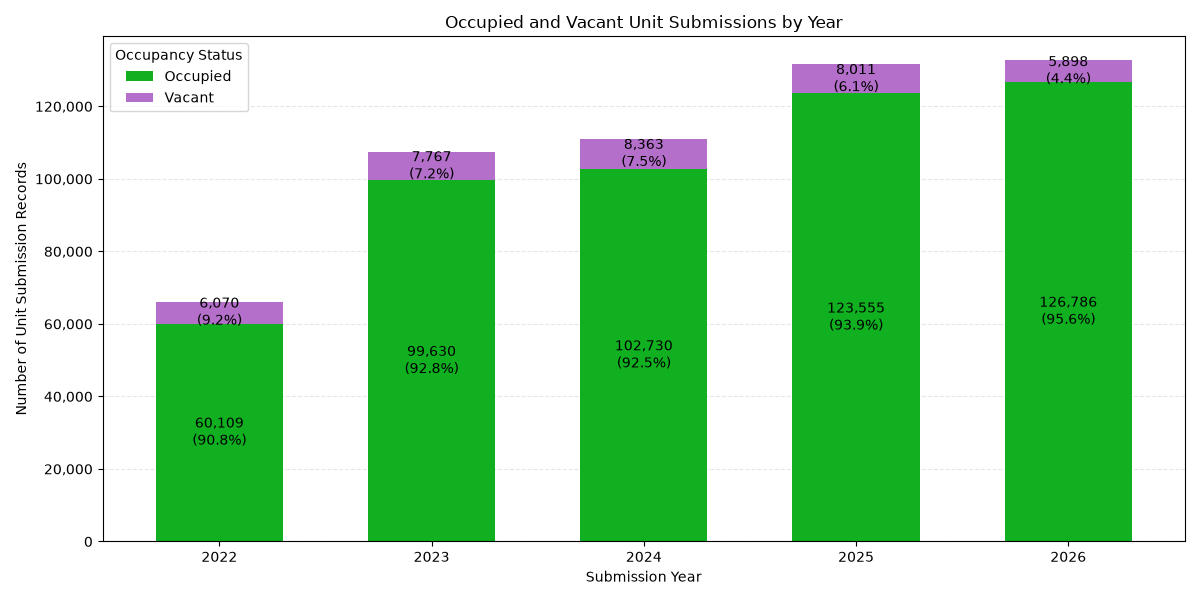

In [ ]:
from matplotlib.ticker import StrMethodFormatter

# Count each occupancy type by submission year
yearly_occupancy = pd.crosstab(
    sf_rent['submission_year'],
    sf_rent['occupancy_type']
)

# Keep the three categories needed for this chart
yearly_occupancy = yearly_occupancy.reindex(
    columns=['Vacant', 'Occupied by non-owner', 'Occupied by owner'],
    fill_value=0
)

# Combine owner-occupied and non-owner-occupied records
yearly_occupancy['Occupied'] = (
    yearly_occupancy['Occupied by non-owner']
    + yearly_occupancy['Occupied by owner']
)

yearly_occupancy = yearly_occupancy[['Occupied', 'Vacant']].sort_index()

# Draw the stacked bar chart
ax = yearly_occupancy.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#10b020', '#b36fc9'],
    width=0.6
)

# Total occupied + vacant records in each year
yearly_totals = yearly_occupancy.sum(axis=1)

# Show the count inside each section
for container in ax.containers:
    labels = []

    for count, total in zip(container.datavalues, yearly_totals):
        if total > 0 and count > 0:
            percentage = count / total * 100
            labels.append(f'{count:,.0f}\n({percentage:.1f}%)')
        else:
            labels.append('')

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10
    )

ax.set_title('Occupied and Vacant Unit Submissions by Year')
ax.set_xlabel('Submission Year')
ax.set_ylabel('Number of Unit Submission Records')
ax.tick_params(axis='x', labelrotation=0)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Occupancy Status')

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 2. What Is the Bedroom Mix in Each Submission Year?

Next, look at the types of apartments represented in the reports. This chart shows the proportions of studios, one-bedroom apartments, two-bedroom apartments, and the remaining bedroom categories in each year. Each stacked bar adds up to 100%.

The labels show the category count and its share of all records with a non-missing bedroom category in that year. Missing bedroom categories are excluded. The `Others` and `5+ Bedrooms` categories remain included because this chart compares categories rather than exact numeric bedroom counts. Sections below 5% are plotted but have no text label to avoid overlap.

This provides the context for the next chart: a category can have more occupied apartments simply because more apartments of that type were reported.


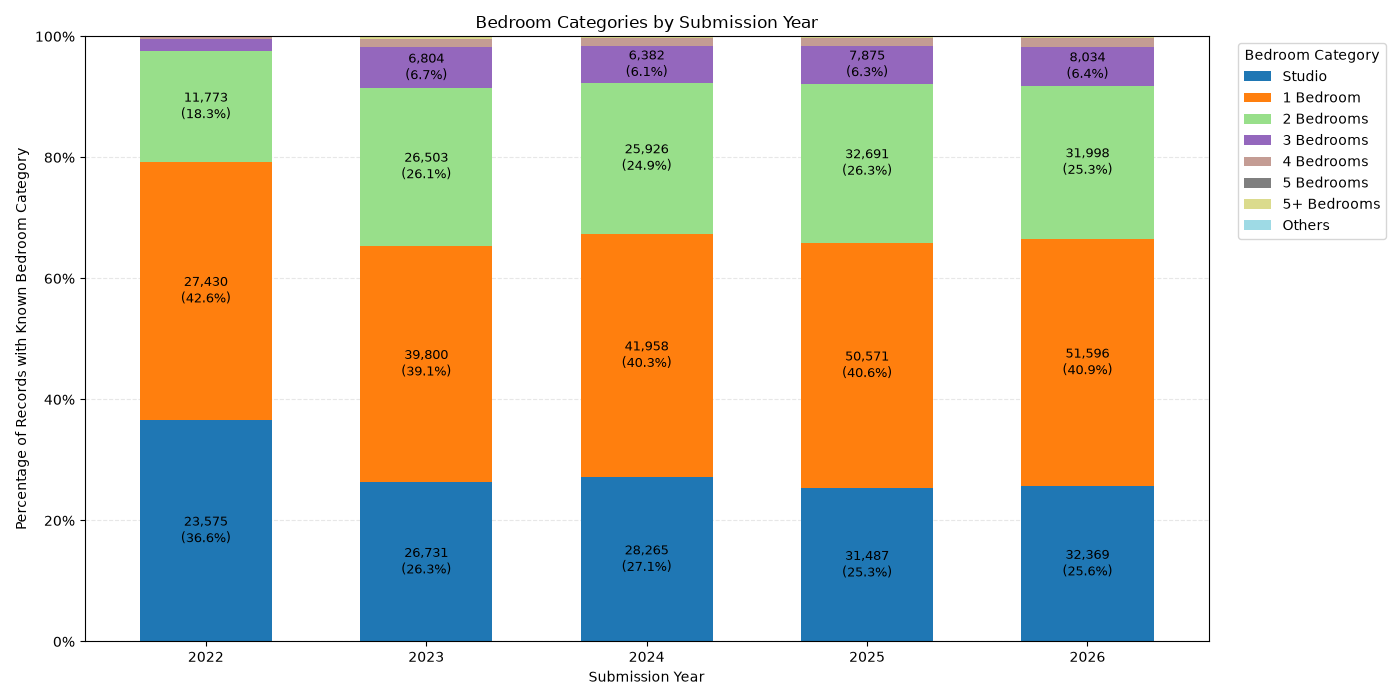

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Total records for each bedroom category and submission year
all_bedrooms = pd.crosstab(
    sf_rent['submission_year'],
    sf_rent['bedroom_category']
).sort_index()

# Put studios first
if 'Studio' in all_bedrooms.columns:
    category_order = ['Studio'] + [
        col for col in all_bedrooms.columns if col != 'Studio'
    ]
    all_bedrooms = all_bedrooms[category_order]

# Select occupied records
occupied = sf_rent[
    sf_rent['occupancy_type'].isin(
        ['Occupied by non-owner', 'Occupied by owner']
    )
]

# Count occupied records for each bedroom category and year
occupied_bedrooms = pd.crosstab(
    occupied['submission_year'],
    occupied['bedroom_category']
)

# Match the years and category order in both tables
occupied_bedrooms = occupied_bedrooms.reindex(
    index=all_bedrooms.index,
    columns=all_bedrooms.columns,
    fill_value=0
)


# CHART 1: Bedroom distribution within each submission year

yearly_totals = all_bedrooms.sum(axis=1)

bedroom_percentages = (
    all_bedrooms.div(yearly_totals, axis=0) * 100
)

ax = bedroom_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20',
    width=0.6
)

for ind, container in enumerate(ax.containers):
    labels = []

    for count, percentage in zip(
        all_bedrooms.iloc[:, ind],
        bedroom_percentages.iloc[:, ind]
    ):
        if percentage >= 5:
            labels.append(f'{count:,.0f}\n({percentage:.1f}%)')
        else:
            labels.append('')

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9
    )

ax.set_title('Bedroom Categories by Submission Year')
ax.set_xlabel('Submission Year')
ax.set_ylabel('Percentage of Records with Known Bedroom Category')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis='x', labelrotation=0)

ax.legend(
    title='Bedroom Category',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()




### 3. What Percentage of Each Bedroom Category Is Reported as Occupied?

Now compare occupancy within each bedroom category. For a given year, divide the occupied records in a category by all records in that same category, then multiply by 100.

**Percentage reported as occupied = occupied category records ÷ total category records in the same year × 100.**

For example, 21,035 of the 23,575 studio records in 2022 were reported as occupied. This gives approximately **89.2%**. Unlike the preceding chart, each category has its own denominator, so the percentages are shown as separate bars and do not need to add up to 100%.

Occupied includes both owners and non-owners. The denominator includes all records with that bedroom category, including any other or missing occupancy status. Therefore, the remaining percentage cannot automatically be described as vacant. A category with no records in a year has no percentage.

This chart helps distinguish a common apartment type from a type with a higher reported occupied percentage. It describes submissions and does not establish tenant preferences or track individual apartments over time.


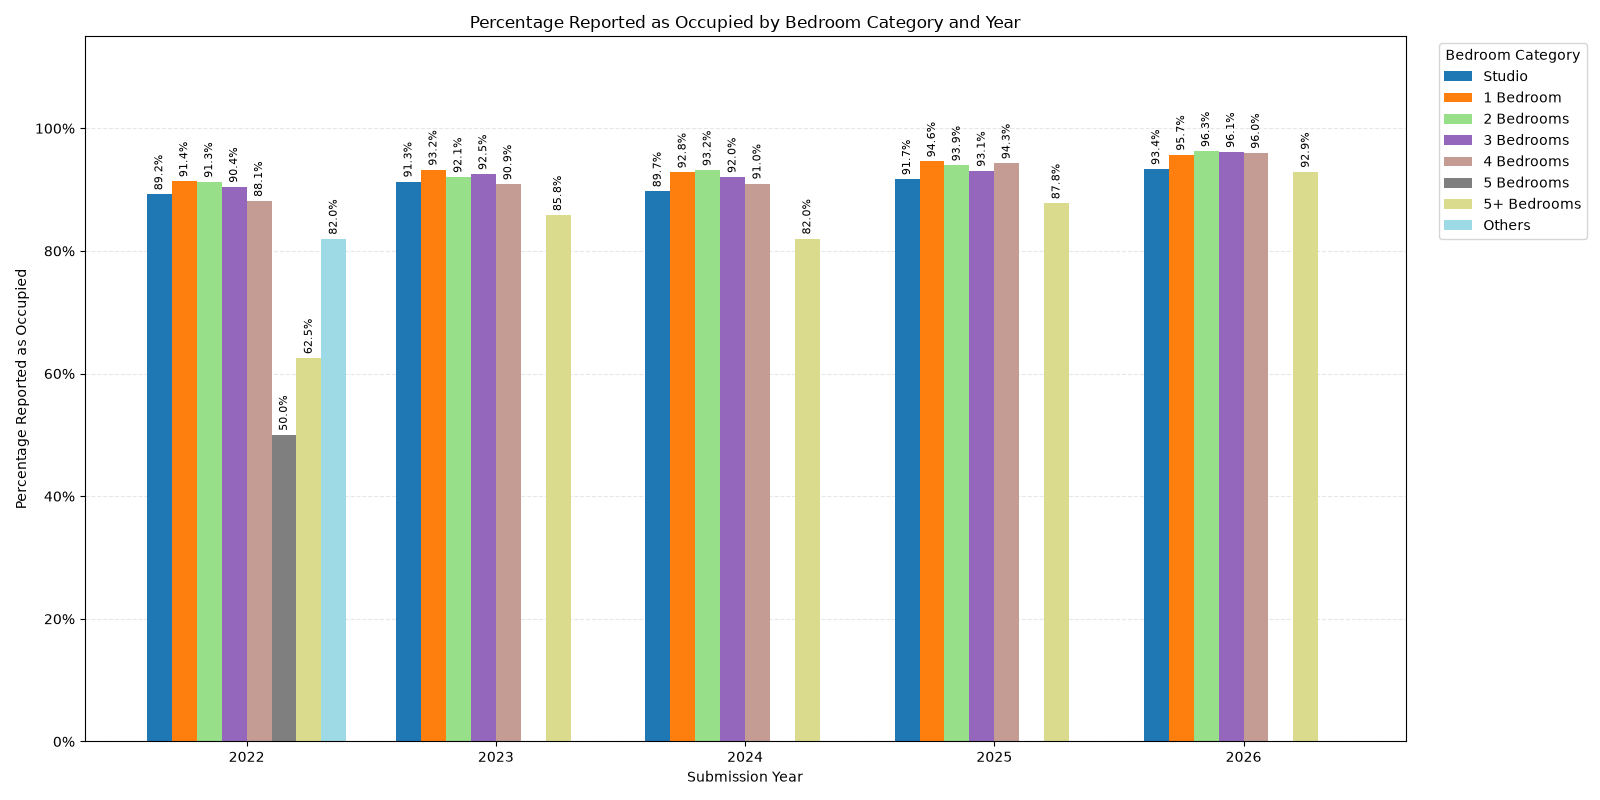

In [ ]:
# CHART 2: Percentage occupied within each bedroom category
# Example: occupied studios / total studios in the same year

occupied_percentages = (
    occupied_bedrooms / all_bedrooms.replace(0, np.nan)
) * 100

ax = occupied_percentages.plot(
    kind='bar',
    stacked=False,
    figsize=(16, 8),
    colormap='tab20',
    width=0.8
)

for ind, container in enumerate(ax.containers):
    labels = []

    # Use the original percentages so absent categories remain unlabeled
    for percentage in occupied_percentages.iloc[:, ind]:
        if pd.notna(percentage):
            labels.append(f'{percentage:.1f}%')
        else:
            labels.append('')

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90,
        fontsize=8
    )

ax.set_title(
    'Percentage Reported as Occupied by Bedroom Category and Year'
)
ax.set_xlabel('Submission Year')
ax.set_ylabel('Percentage Reported as Occupied')
ax.set_ylim(0, 115)
ax.set_yticks(range(0, 101, 20))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis='x', labelrotation=0)

ax.legend(
    title='Bedroom Category',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Explore All Submission Years Together

The following charts give an overview of the reported housing units across all submission years. Bar charts show how often each bedroom and bathroom count appears. Histograms group rent, square footage, and property age into ranges and show how many records fall in each range.

The red dashed line marks the median: the middle value after the available values are put in order. Each chart uses the records with a usable value for that feature, so the number of records can differ between charts. These medians describe each feature separately; they do not identify one apartment with all of the median characteristics.

The heatmap shows correlation, which measures how two numeric features vary together. A positive value means they tend to increase together; a negative value means one tends to decrease as the other increases. Values closer to zero show a weaker straight-line relationship. A diagonal value of 1 compares a feature with itself. Correlation describes an association and does not establish its cause.


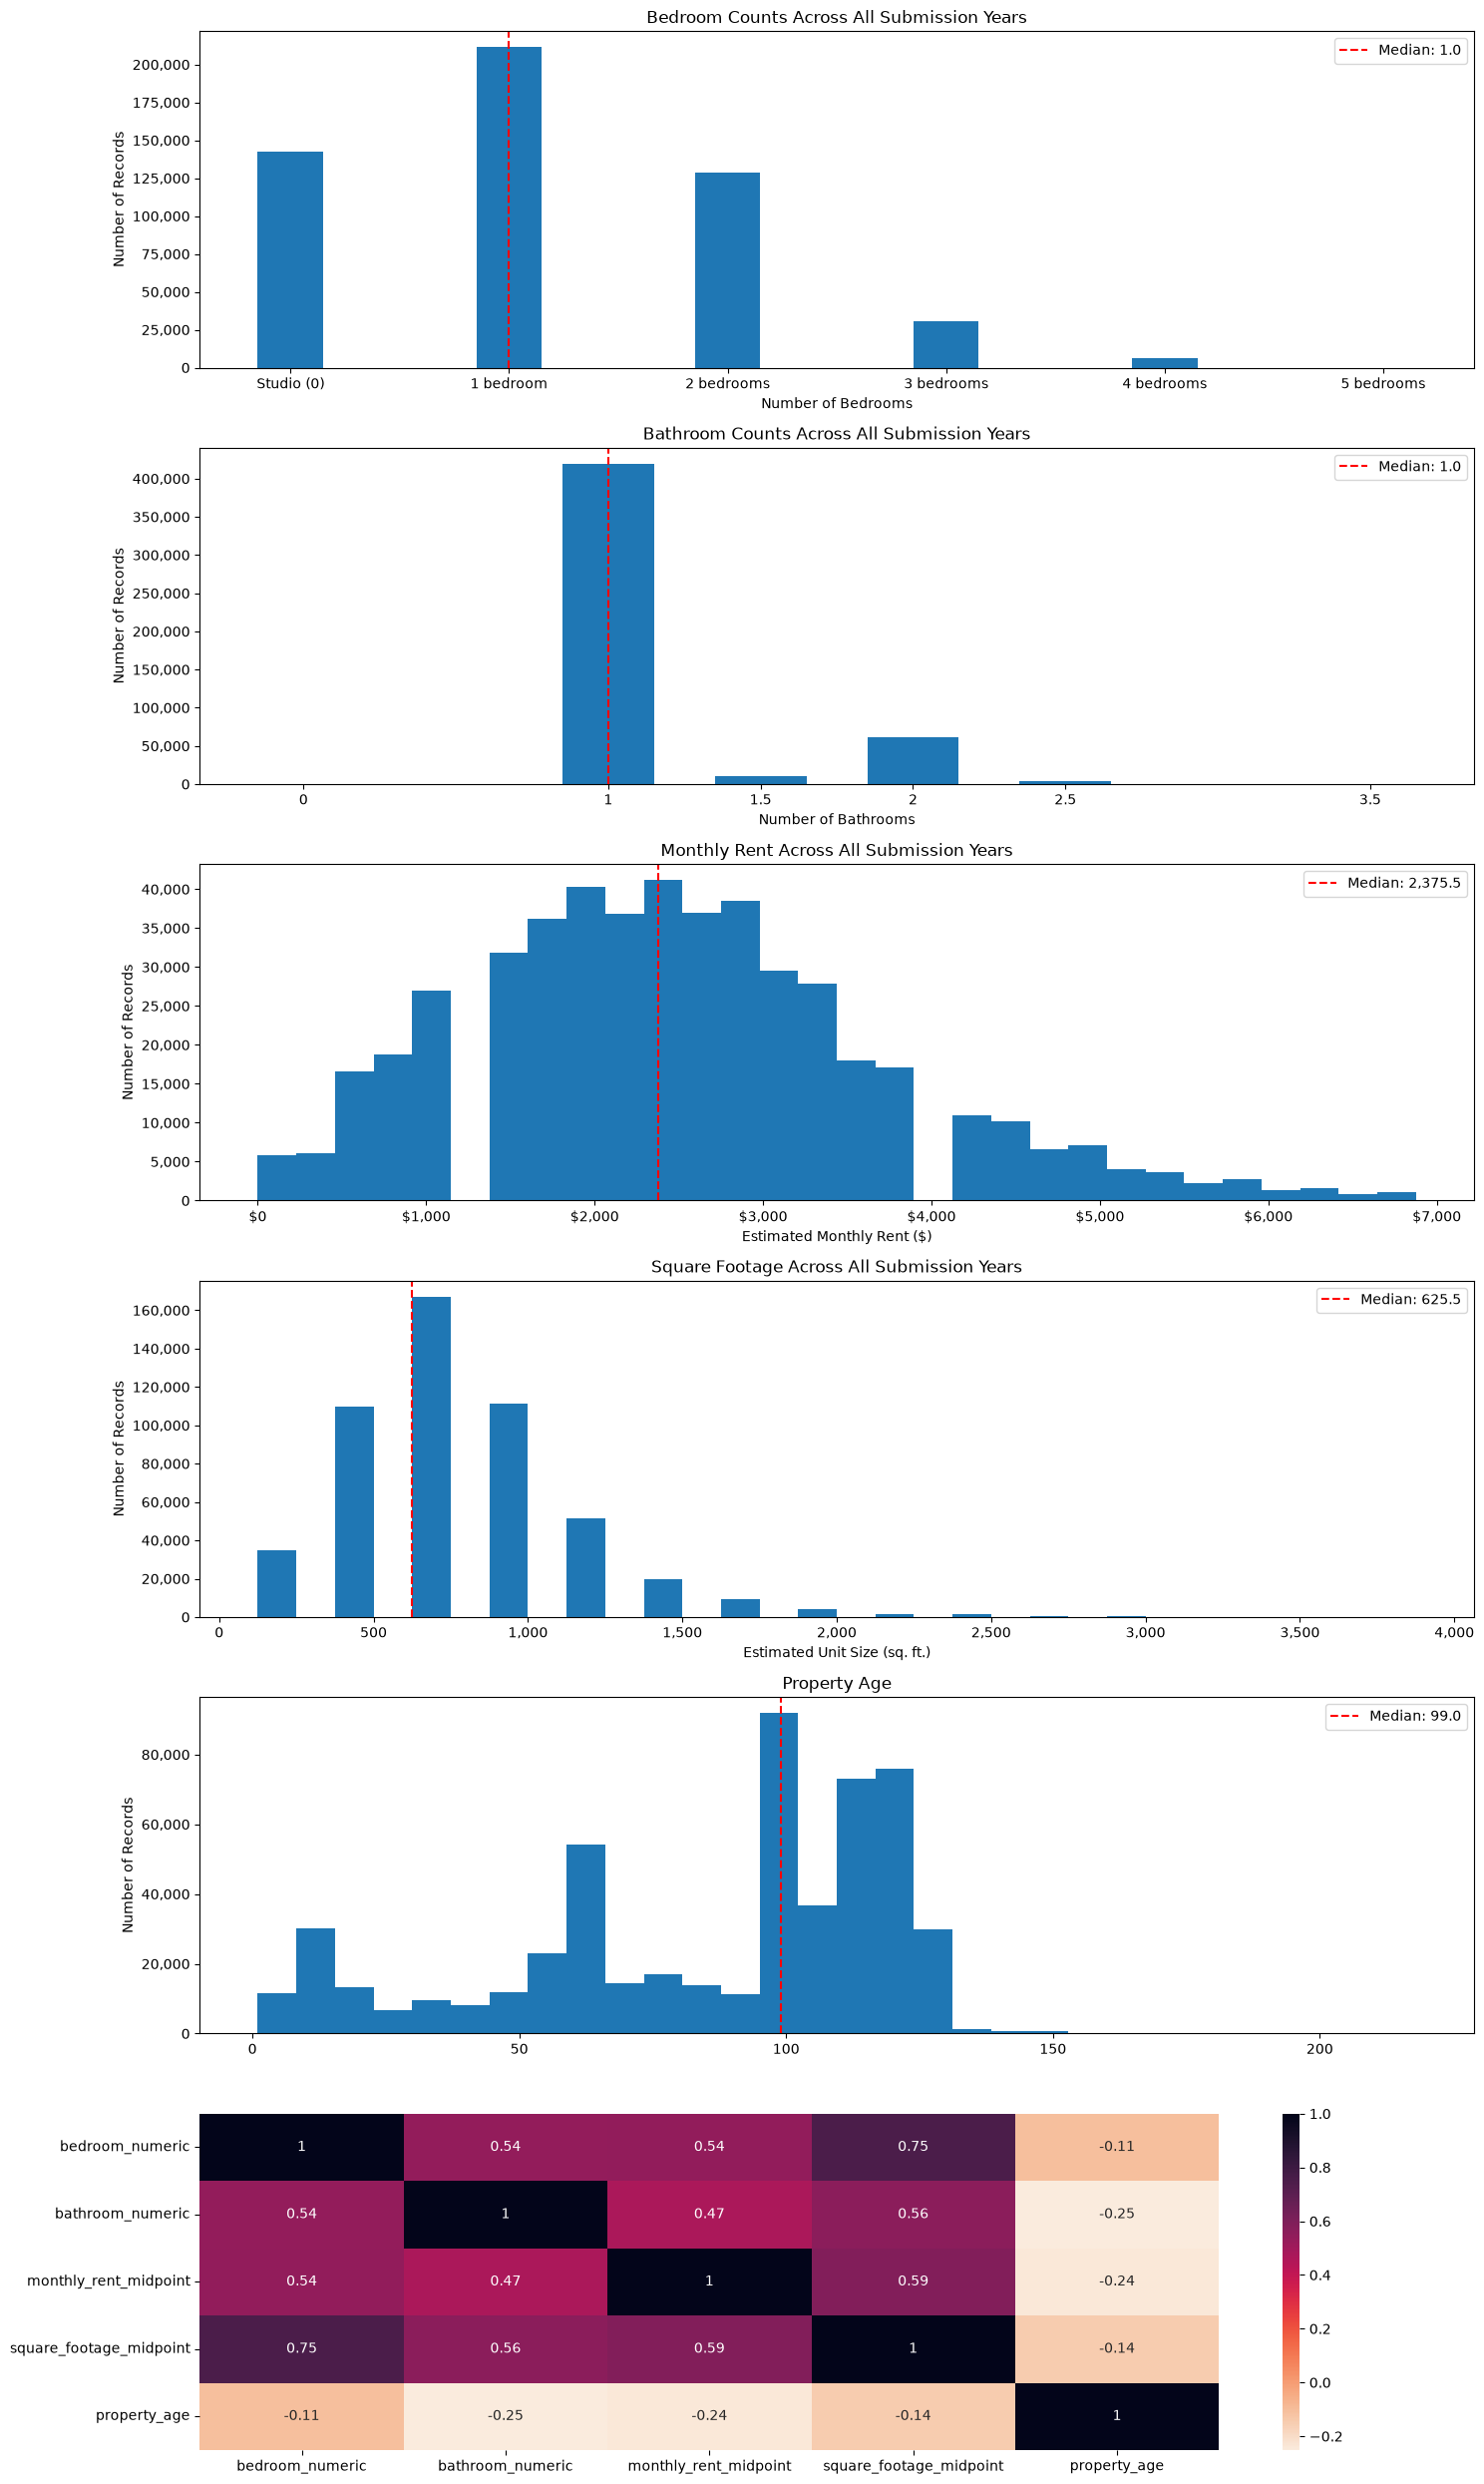

In [57]:
from matplotlib.ticker import StrMethodFormatter

columns = [
    'bedroom_numeric',
    'bathroom_numeric',
    'monthly_rent_midpoint',
    'square_footage_midpoint',
    'property_age'
]

titles = {
    'bedroom_numeric': 'Bedroom Counts Across All Submission Years',
    'bathroom_numeric': 'Bathroom Counts Across All Submission Years',
    'monthly_rent_midpoint': 'Monthly Rent Across All Submission Years',
    'square_footage_midpoint': 'Square Footage Across All Submission Years',
    'property_age': 'Property Age'
}

fig, axes = plt.subplots(6, 1, figsize=(15, 25))

for ind, col in enumerate(columns):
    values = sf_rent[col].dropna()
    ax = axes[ind]

    # Bar charts for room counts; histograms for rent and size
    if col in ['bedroom_numeric', 'bathroom_numeric']:
        counts = values.value_counts().sort_index()
        ax.bar(counts.index, counts.values, width=0.3)
    else:
        ax.hist(values, bins=30)

    # Set readable x-axis labels and ticks
    if col == 'bedroom_numeric':
        ax.set_xlabel('Number of Bedrooms')
        ax.set_xticks(
            [0, 1, 2, 3, 4, 5],
            ['Studio (0)', '1 bedroom', '2 bedrooms',
             '3 bedrooms', '4 bedrooms', '5 bedrooms']
        )

    elif col == 'bathroom_numeric':
        ax.set_xlabel('Number of Bathrooms')
        ax.set_xticks(
            [0, 1, 1.5, 2, 2.5, 3.5],
            ['0', '1', '1.5', '2', '2.5', '3.5']
        )

    elif col == 'monthly_rent_midpoint':
        ax.set_xlabel('Estimated Monthly Rent ($)')
        ax.set_xticks(range(0, 7001, 1000))
        ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

    elif col == 'square_footage_midpoint':
        ax.set_xlabel('Estimated Unit Size (sq. ft.)')
        ax.set_xticks(range(0, 4001, 500))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    median_val = values.median()
    ax.axvline(
        median_val, color='red', linestyle='--',
        label=f'Median: {median_val:,.1f}'
    )

    ax.set_title(titles[col])
    ax.set_ylabel('Number of Records')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.legend()

# Correlation    
correl = sf_rent[columns].corr()

sns.heatmap(correl, annot = True, ax = axes[len(columns)], cmap = 'rocket_r' )

plt.tight_layout()
plt.show()




### What the Combined Charts Show

Across all submission years, the median among usable values is **1 bedroom**, **1 bathroom**, **$2,375.50 in estimated monthly rent**, **625.5 square feet in estimated square footage**, and **99 years in property age**, measured in 2026.

Bedroom count and estimated square footage have a correlation of about **0.75**, meaning apartments with more bedrooms tend to have more square footage. Estimated rent and estimated square footage have a correlation of about **0.59**, meaning larger apartments tend to have higher reported rents. Property age and estimated rent have a correlation of about **−0.24**, a weaker negative association in these records.

These results summarize the available submissions. Missing values and categories without an exact numeric value are excluded from the relevant calculation. The combined charts also include repeated annual reports, so they should not be interpreted as a snapshot of all different apartments in San Francisco.


### 5. Explore Each Submission Year Separately

Repeat the same analysis for each submission year from 2022 through 2026. Each figure uses only that year's records, including its median lines and correlation heatmap.

The histogram ranges are kept the same across years so that the distributions are easier to compare. The chart titles show how many records have a usable value and how many records were submitted in that year. Years with more submissions can have taller bars even when their distributions are similar, so compare the overall shape as well as the counts.

Property age still uses the current calendar year, following the calculation above. For example, a property built in 1926 has an age of 100 in 2026, even when its submission is from 2022. These charts compare the properties represented in each year's records; they do not calculate age at the time of submission.


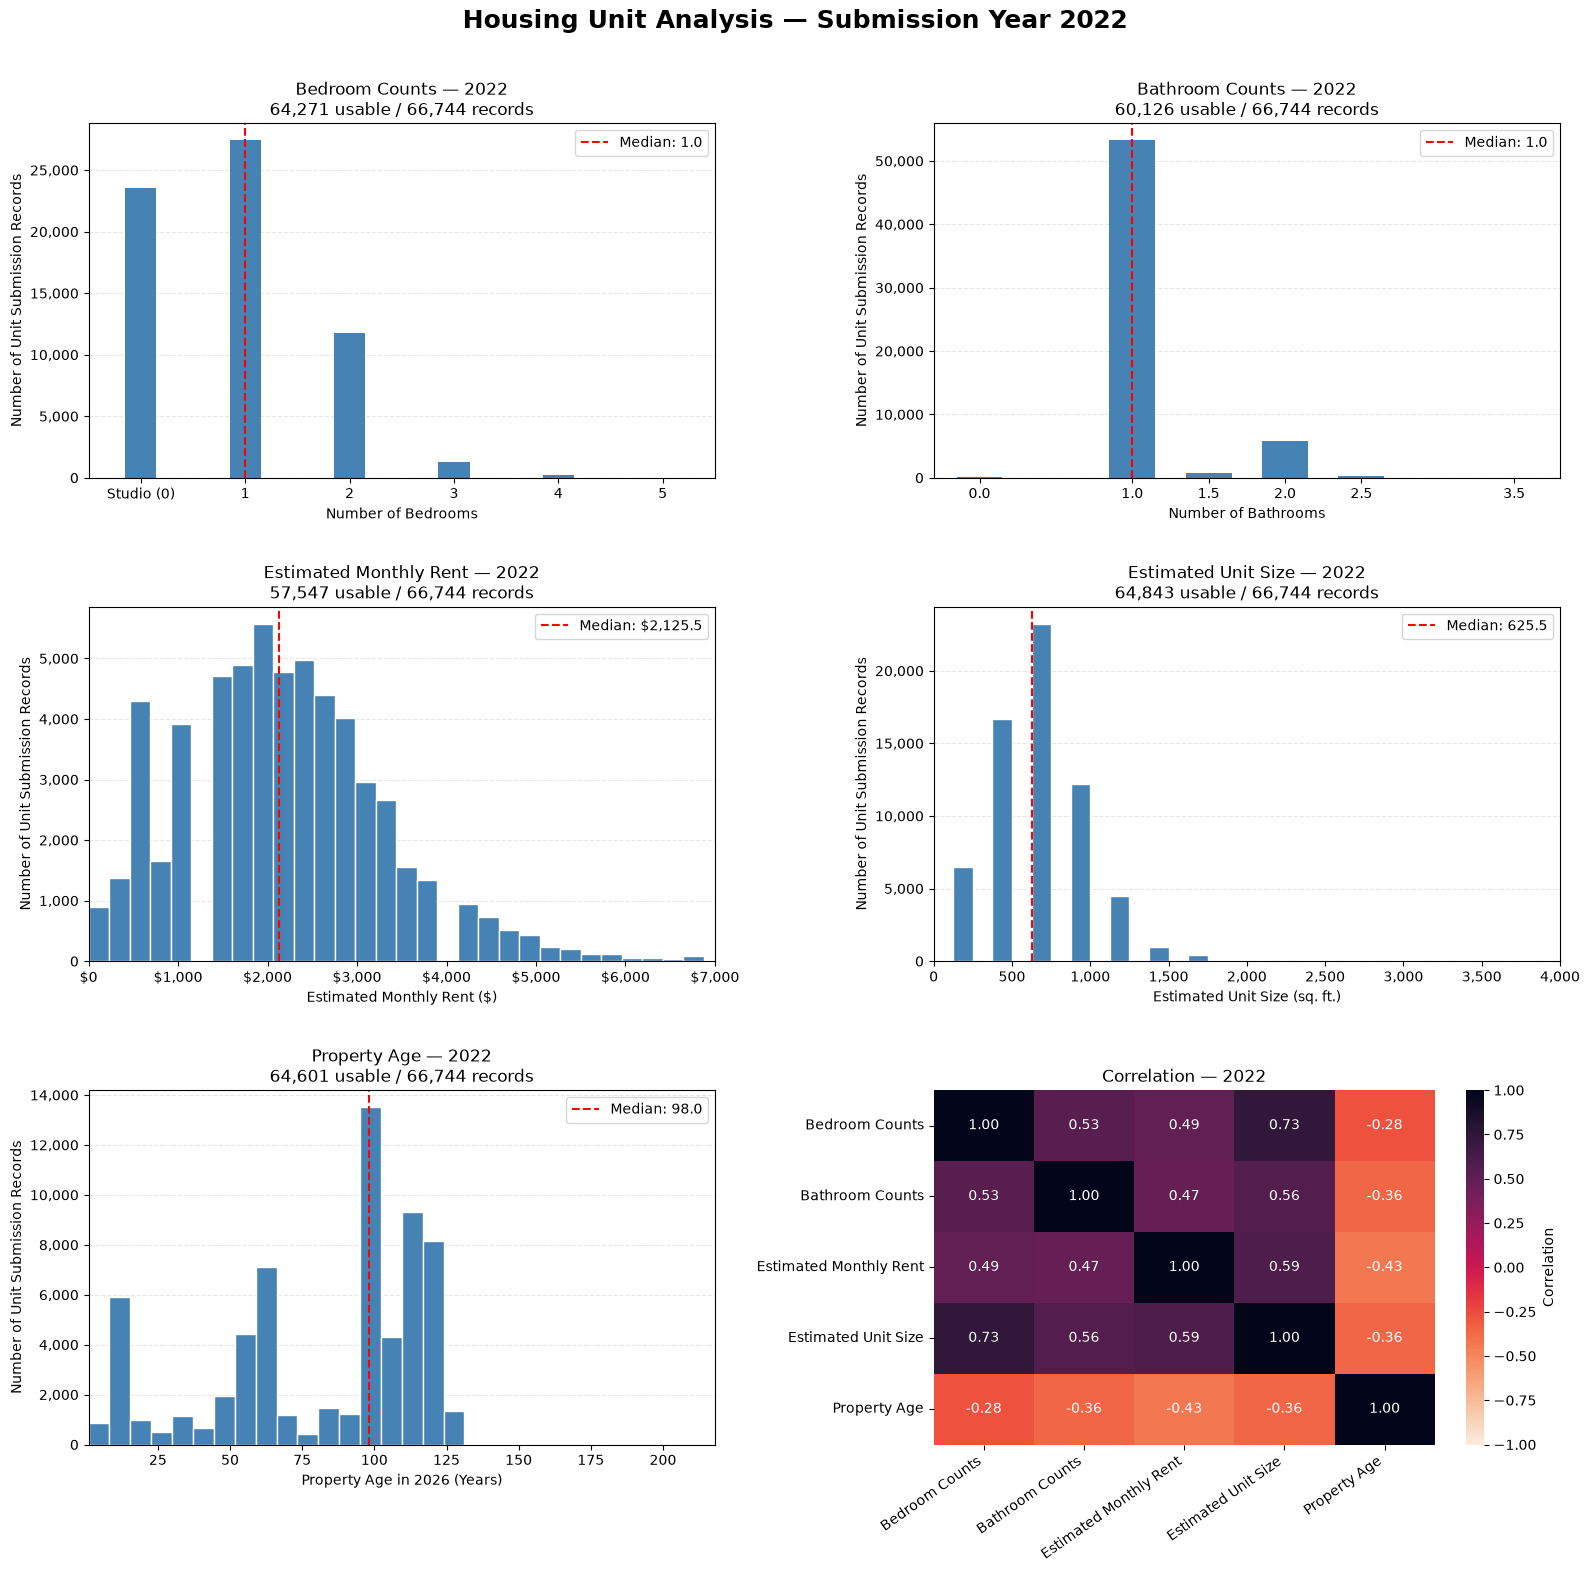

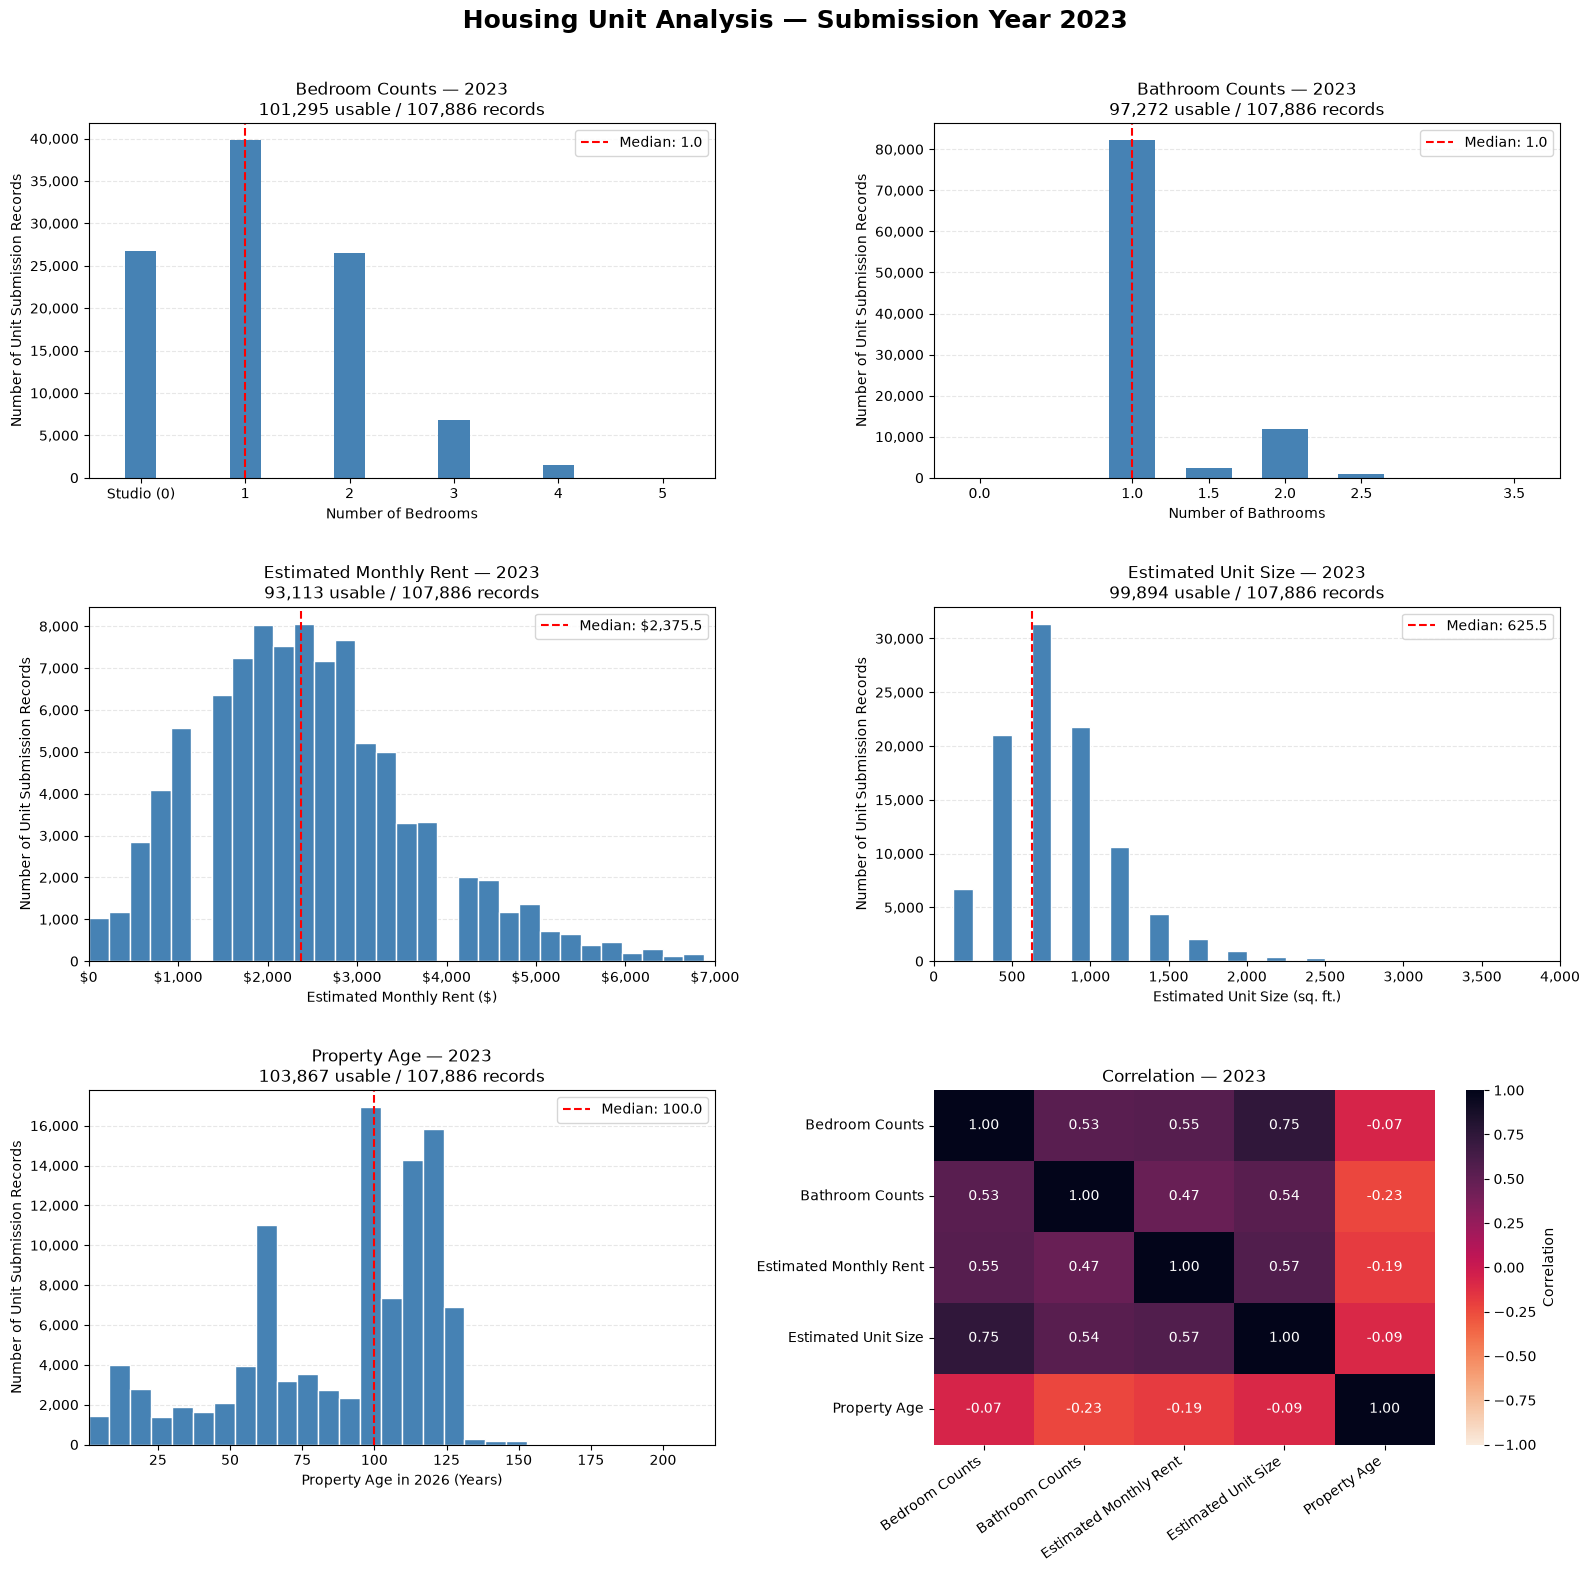

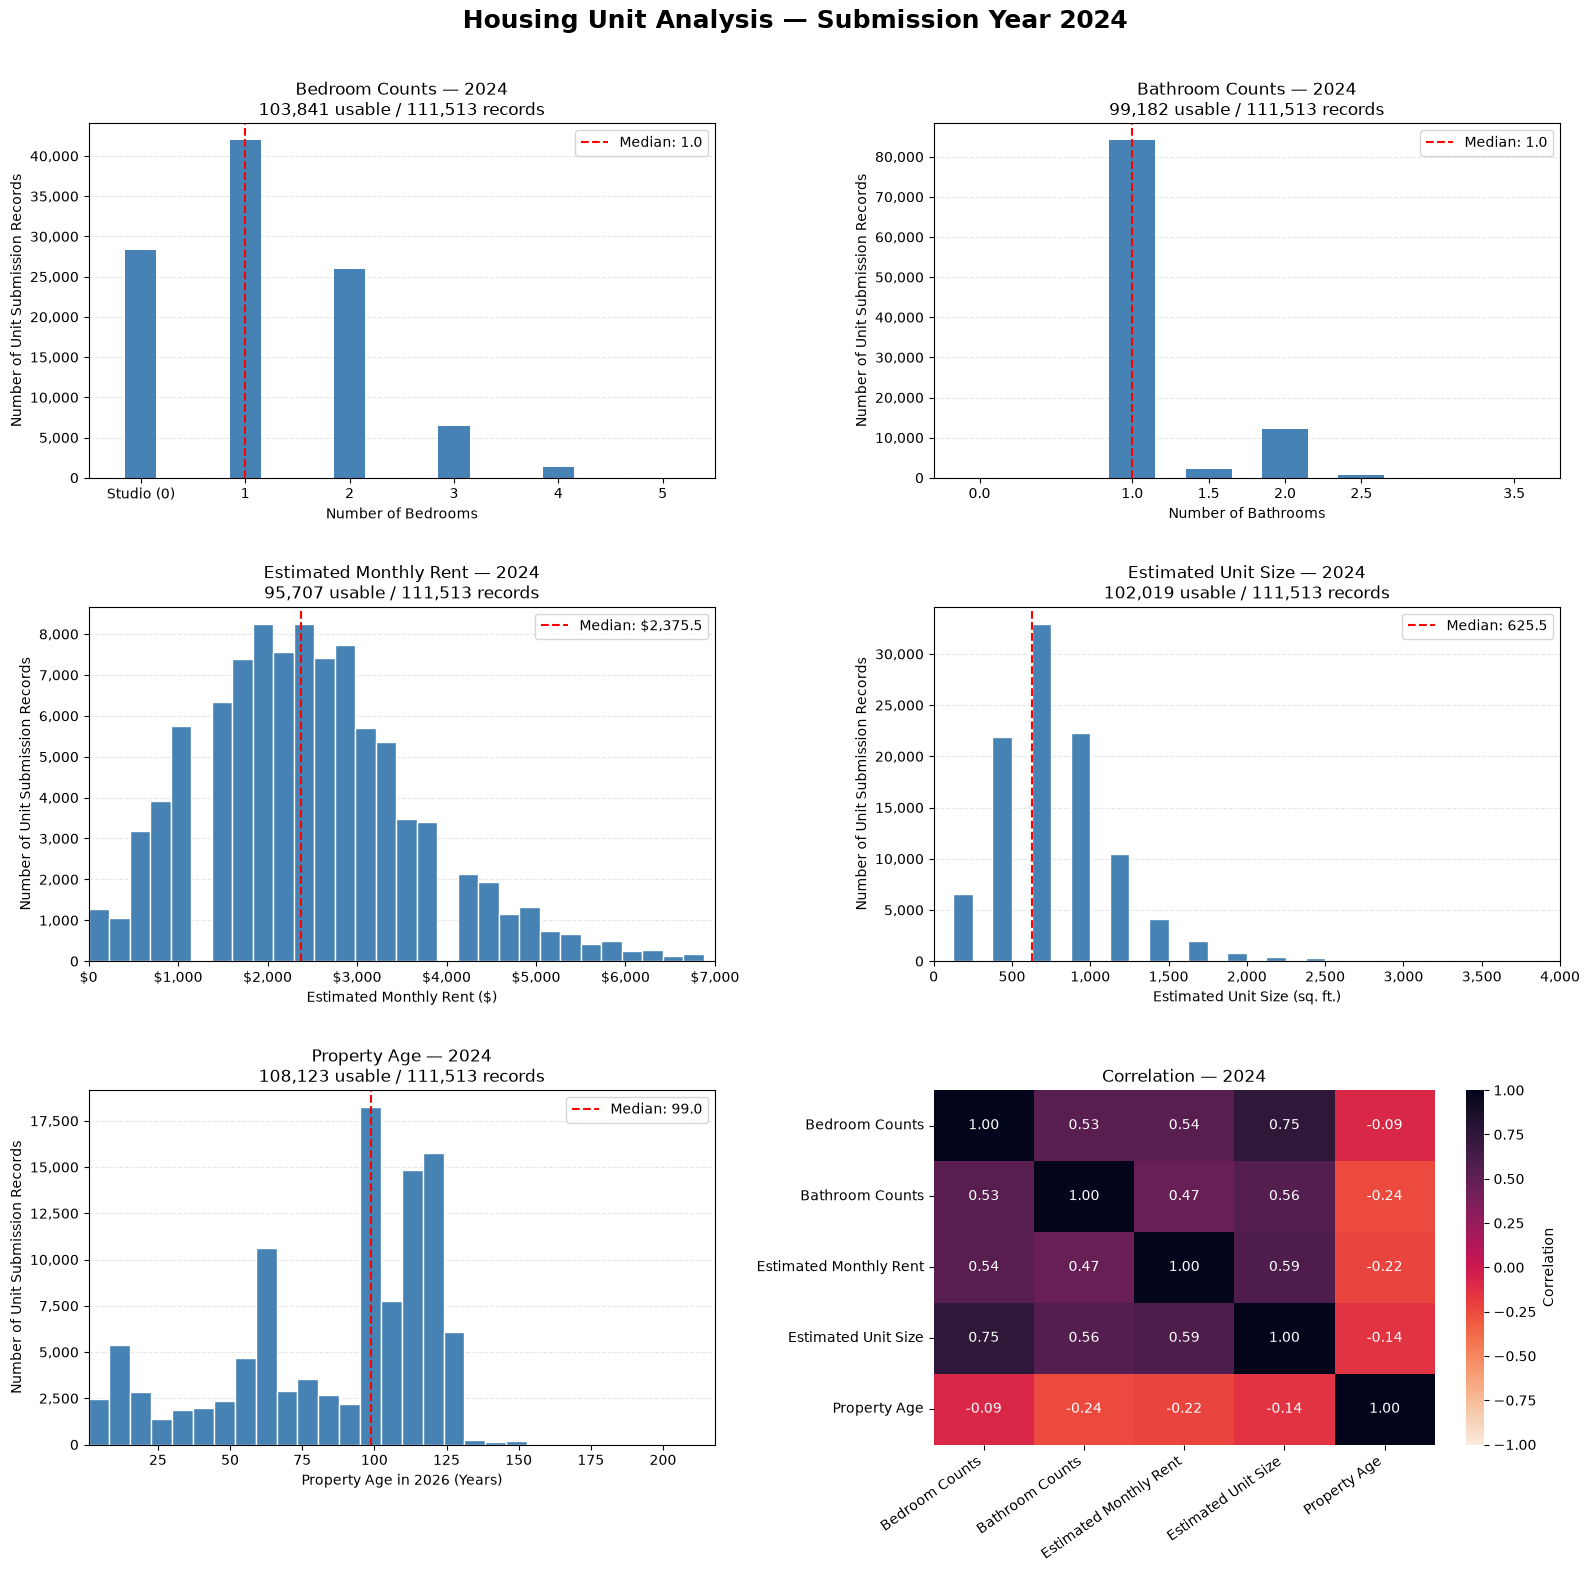

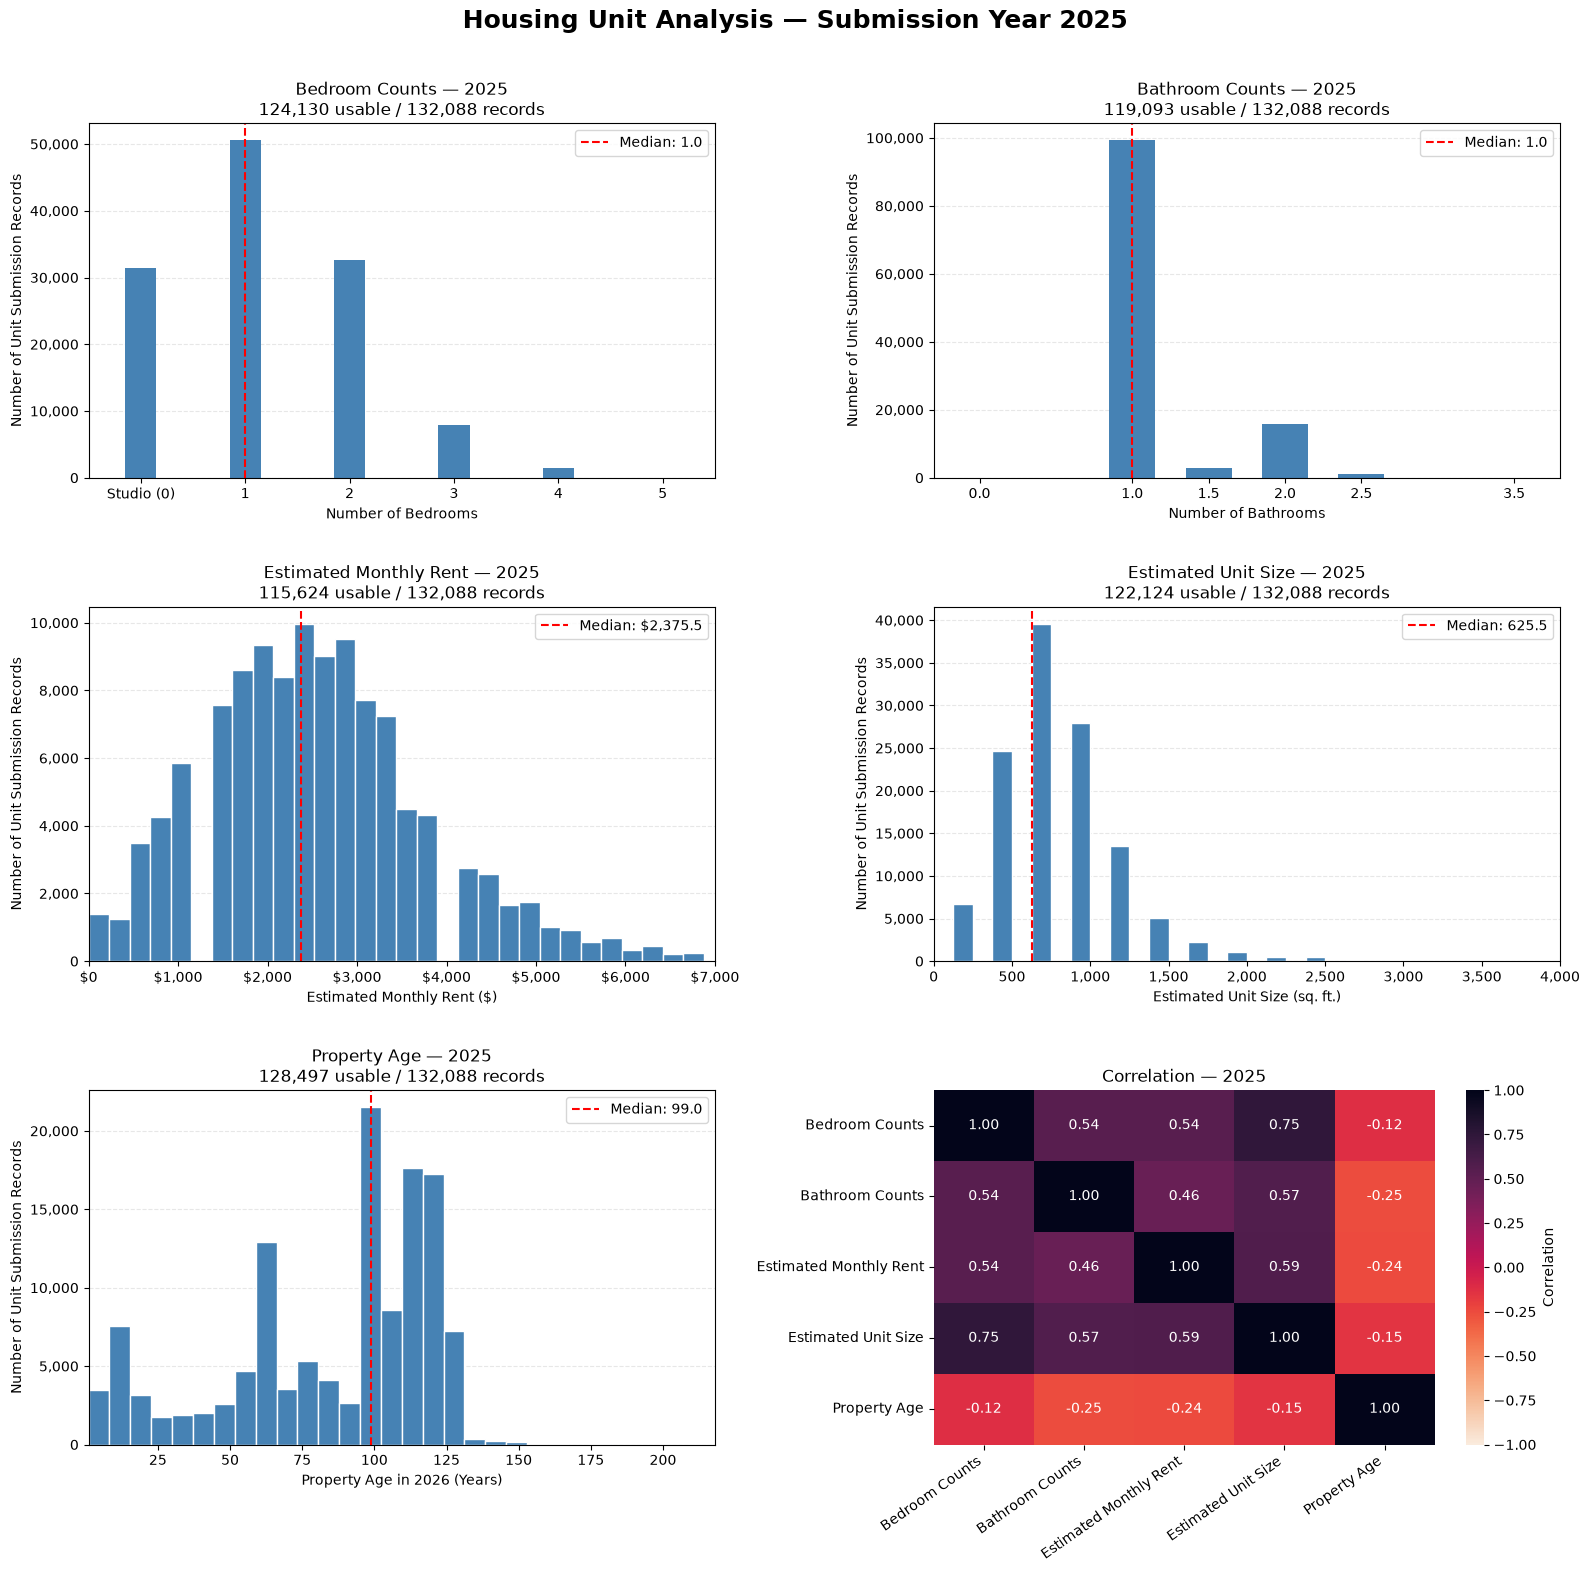

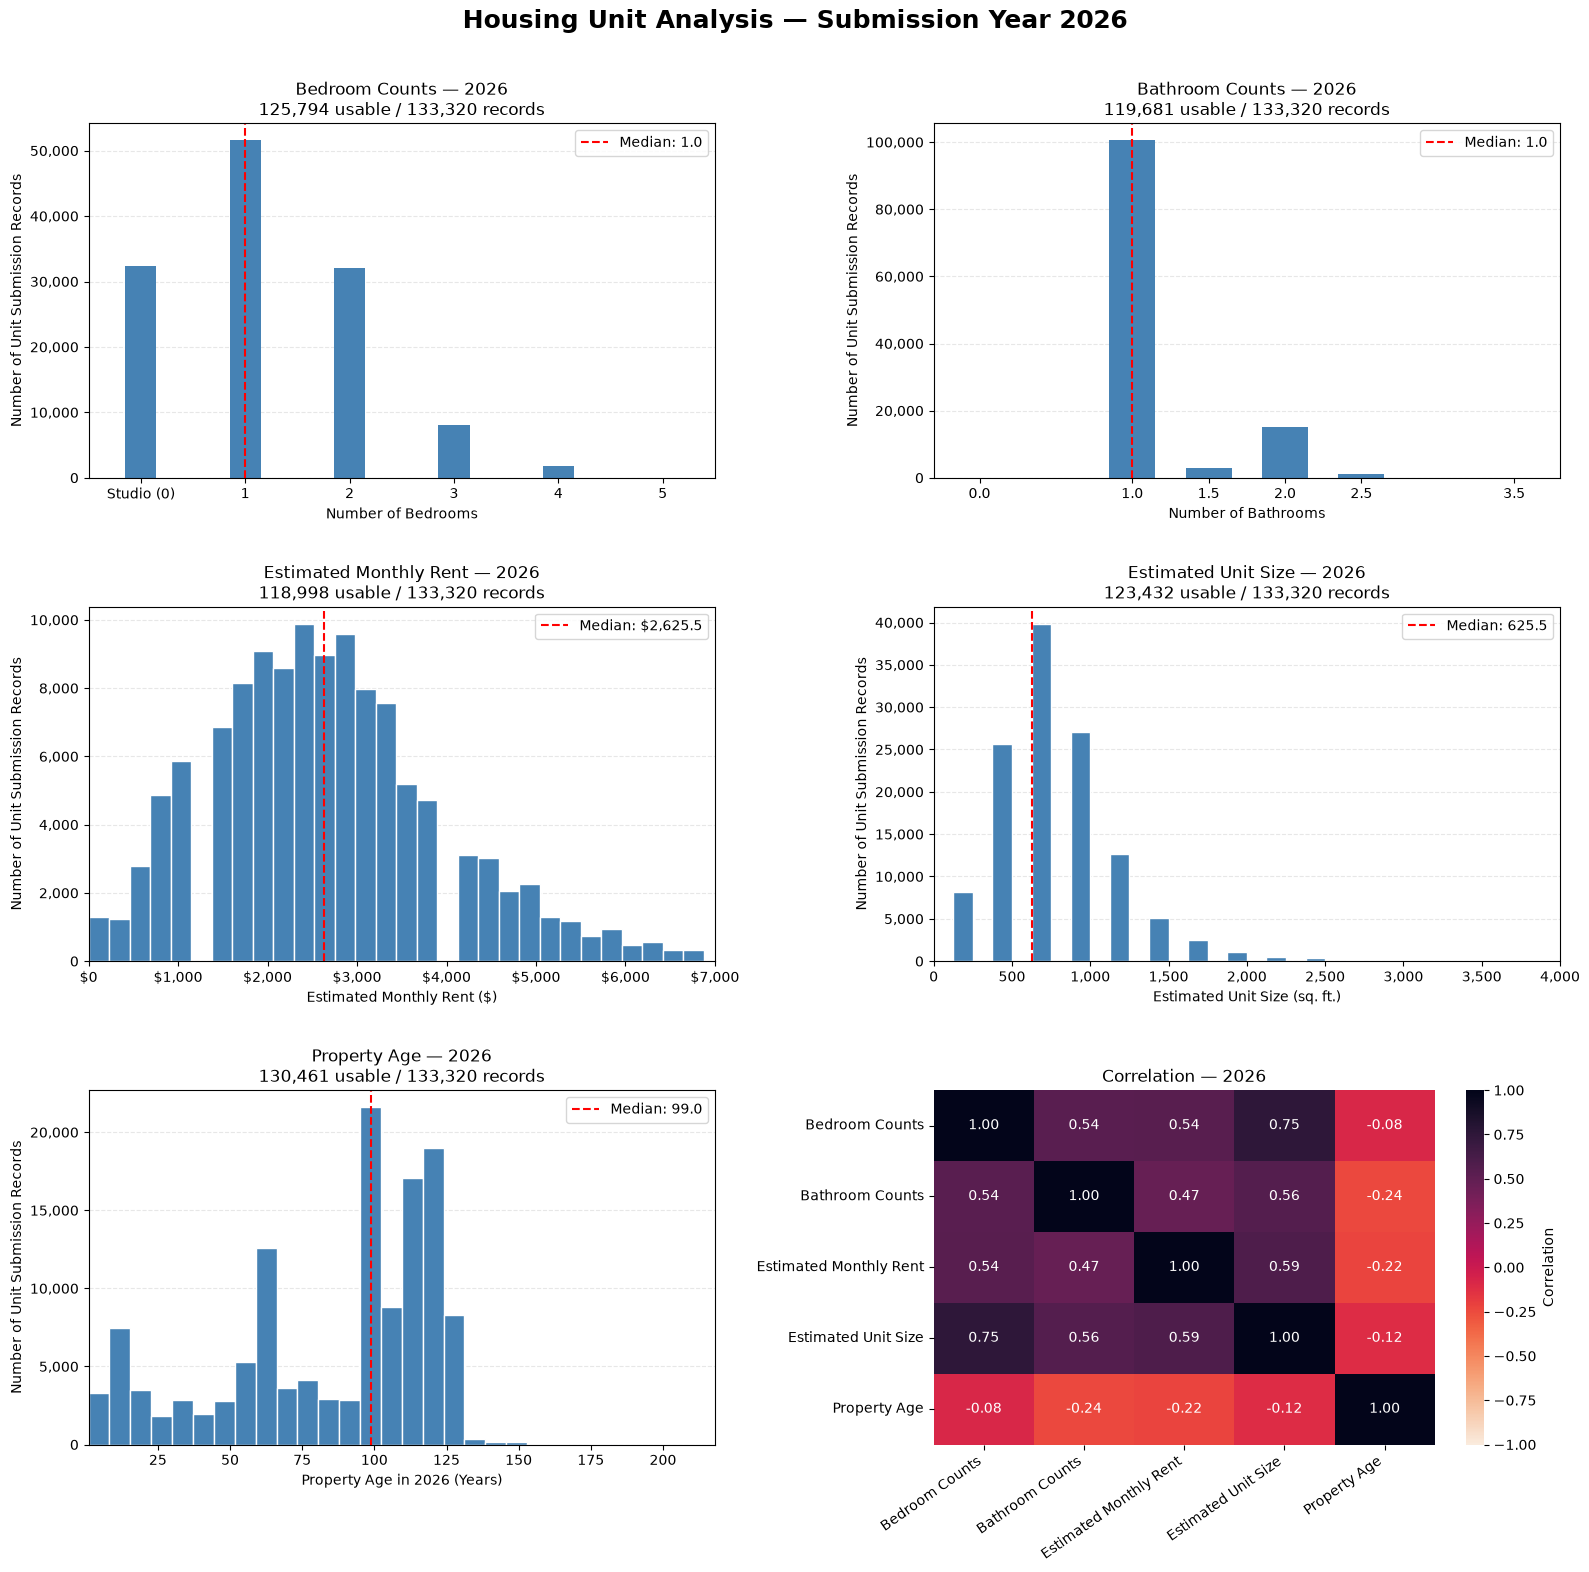

In [37]:
from matplotlib.ticker import StrMethodFormatter

columns = [
    'bedroom_numeric',
    'bathroom_numeric',
    'monthly_rent_midpoint',
    'square_footage_midpoint',
    'property_age'
]

titles = {
    'bedroom_numeric': 'Bedroom Counts',
    'bathroom_numeric': 'Bathroom Counts',
    'monthly_rent_midpoint': 'Estimated Monthly Rent',
    'square_footage_midpoint': 'Estimated Unit Size',
    'property_age': 'Property Age'
}

# Keep histogram bins consistent across years
histogram_bins = {}

for col in ['monthly_rent_midpoint',
            'square_footage_midpoint',
            'property_age']:
    histogram_bins[col] = np.histogram_bin_edges(
        sf_rent[col].dropna().to_numpy(dtype=float),
        bins=30
    )

years = sorted(sf_rent['submission_year'].dropna().unique())

for year in years:

    # Select records from this year only
    year_data = sf_rent[sf_rent['submission_year'] == year]

    fig, axes = plt.subplots(3, 2, figsize=(16, 16))
    axes = axes.flatten()

    for ind, col in enumerate(columns):
        values = year_data[col].dropna()
        ax = axes[ind]

        # Bar charts for bedrooms and bathrooms
        if col in ['bedroom_numeric', 'bathroom_numeric']:
            counts = values.value_counts().sort_index()
            ax.bar(
                counts.index, counts.values,
                width=0.3, color='steelblue'
            )

        # Histograms for rent, square footage, and age
        else:
            ax.hist(
                values.to_numpy(dtype=float),
                bins=histogram_bins[col],
                color='steelblue',
                edgecolor='white'
            )
            ax.set_xlim(
                histogram_bins[col][0],
                histogram_bins[col][-1]
            )

        # Readable x-axis labels
        if col == 'bedroom_numeric':
            ax.set_xlabel('Number of Bedrooms')
            ax.set_xticks(
                [0, 1, 2, 3, 4, 5],
                ['Studio (0)', '1', '2', '3', '4', '5']
            )
            ax.set_xlim(-0.5, 5.5)

        elif col == 'bathroom_numeric':
            ax.set_xlabel('Number of Bathrooms')
            ax.set_xticks([0, 1, 1.5, 2, 2.5, 3.5])
            ax.set_xlim(-0.3, 3.8)

        elif col == 'monthly_rent_midpoint':
            ax.set_xlabel('Estimated Monthly Rent ($)')
            ax.set_xticks(range(0, 7001, 1000))
            ax.xaxis.set_major_formatter(
                StrMethodFormatter('${x:,.0f}')
            )

        elif col == 'square_footage_midpoint':
            ax.set_xlabel('Estimated Unit Size (sq. ft.)')
            ax.set_xticks(range(0, 4001, 500))
            ax.xaxis.set_major_formatter(
                StrMethodFormatter('{x:,.0f}')
            )

        elif col == 'property_age':
            ax.set_xlabel(
                f'Property Age in {pd.Timestamp.today().year} (Years)'
            )

        # Calculate the median using this year's values
        if not values.empty:
            median_val = values.median()

            if col == 'monthly_rent_midpoint':
                median_label = f'Median: ${median_val:,.1f}'
            else:
                median_label = f'Median: {median_val:,.1f}'

            ax.axvline(
                median_val,
                color='red',
                linestyle='--',
                label=median_label
            )
            ax.legend()

        ax.set_title(
            f'{titles[col]} — {int(year)}\n'
            f'{len(values):,} usable / {len(year_data):,} records'
        )
        ax.set_ylabel('Number of Unit Submission Records')
        ax.yaxis.set_major_formatter(
            StrMethodFormatter('{x:,.0f}')
        )
        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Correlation heatmap for this year only
    correl = year_data[columns].corr()
    correl = correl.rename(index=titles, columns=titles)

    sns.heatmap(
        correl,
        annot=True,
        fmt='.2f',
        ax=axes[5],
        cmap='rocket_r',
        vmin=-1,
        vmax=1,
        cbar_kws={'label': 'Correlation'}
    )

    axes[5].set_title(f'Correlation — {int(year)}')
    axes[5].tick_params(axis='x', labelrotation=35)
    axes[5].tick_params(axis='y', labelrotation=0)

    for label in axes[5].get_xticklabels():
        label.set_ha('right')

    fig.suptitle(
        f'Housing Unit Analysis — Submission Year {int(year)}',
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3, w_pad=3)
    plt.show()

### What the Yearly Charts Show

The table below summarizes the estimated monthly rent medians calculated from the available rent midpoints.

| Submission year | Total submission records | Usable rent records | Median estimated monthly rent |
|---|---:|---:|---:|
| 2022 | 66,744 | 57,547 | $2,125.50 |
| 2023 | 107,886 | 93,113 | $2,375.50 |
| 2024 | 111,513 | 95,707 | $2,375.50 |
| 2025 | 132,088 | 115,624 | $2,375.50 |
| 2026 | 133,320 | 118,998 | $2,625.50 |

The median estimated rent is higher in the 2026 submissions than in the 2022 submissions, and is unchanged at the midpoint level from 2023 through 2025. The median bedroom count is 1, the median bathroom count is 1, and the median estimated square footage is 625.5 in every submission year.

The records included in each year may represent different apartments, and the number of reports also changes. Therefore, this comparison does not tell us how much the rent of the same apartment increased. The use of reported rent ranges also means small changes within a range may not appear in the midpoint summaries.


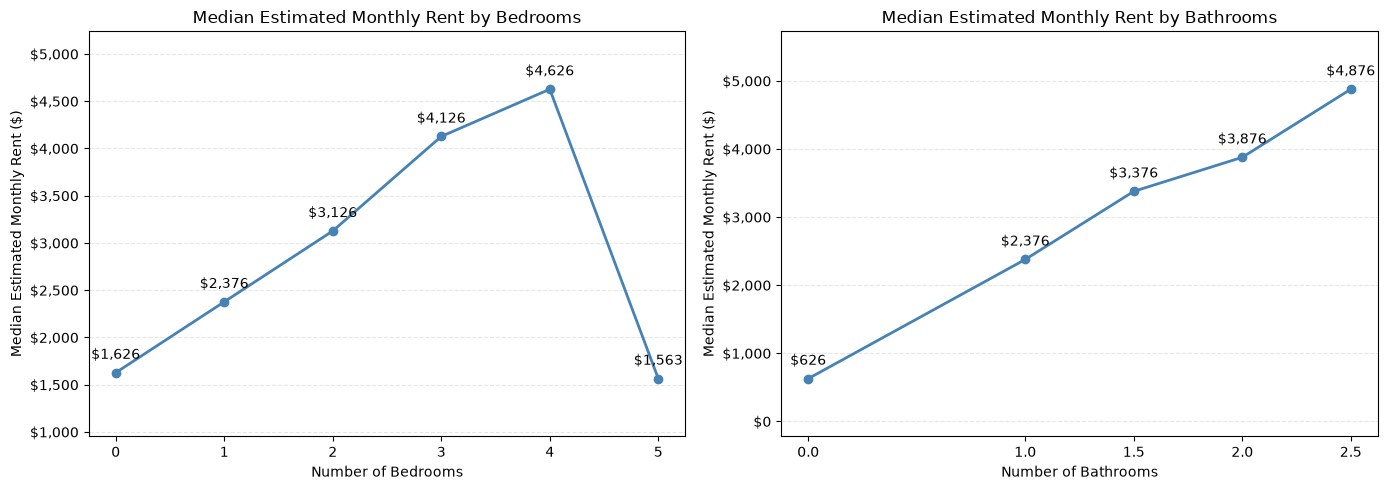


Rent by bedrooms


,median_rent,records
bedroom_numeric,,
0.000000,"$1,625.50","129,925"
1.000000,"$2,375.50","197,821"
2.000000,"$3,125.50","119,785"
3.000000,"$4,125.50","26,751"
4.000000,"$4,625.50","4,967"
5.000000,"$1,562.75",2



Rent by bathrooms


,median_rent,records
bathroom_numeric,,
0.000000,$625.50,83
1.000000,"$2,375.50","392,924"
1.500000,"$3,375.50","10,222"
2.000000,"$3,875.50","55,139"
2.500000,"$4,875.50","2,886"


In [59]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_columns = [
    ("bedroom_numeric", "Bedrooms"),
    ("bathroom_numeric", "Bathrooms")
]

rent_by_rooms = {}

for ax, (column, label) in zip(axes, room_columns):

    # Keep records with a usable room count and rent estimate
    usable = sf_rent.dropna(
        subset=[column, "monthly_rent_midpoint"]
    )

    # Calculate the median rent and number of records at each count
    summary = (
        usable.groupby(column)["monthly_rent_midpoint"]
        .agg(median_rent="median", records="size")
        .sort_index()
    )

    rent_by_rooms[column] = summary

    ax.plot(
        summary.index.astype(float),
        summary["median_rent"].astype(float),
        marker="o",
        linewidth=2,
        color="steelblue"
    )

    # Show the median rent beside each point
    for count, row in summary.iterrows():
        ax.annotate(
            f'${row["median_rent"]:,.0f}',
            (float(count), float(row["median_rent"])),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center"
        )

    ax.set_title(f"Median Estimated Monthly Rent by {label}")
    ax.set_xlabel(f"Number of {label}")
    ax.set_ylabel("Median Estimated Monthly Rent ($)")
    ax.set_xticks(summary.index.astype(float))
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.margins(y=0.2)

plt.tight_layout()
plt.show()

# Display the values used in the charts
for column, label in room_columns:
    print(f"\nRent by {label.lower()}")
    display(
        rent_by_rooms[column].style.format({
            "median_rent": "${:,.2f}",
            "records": "{:,.0f}"
        })
    )

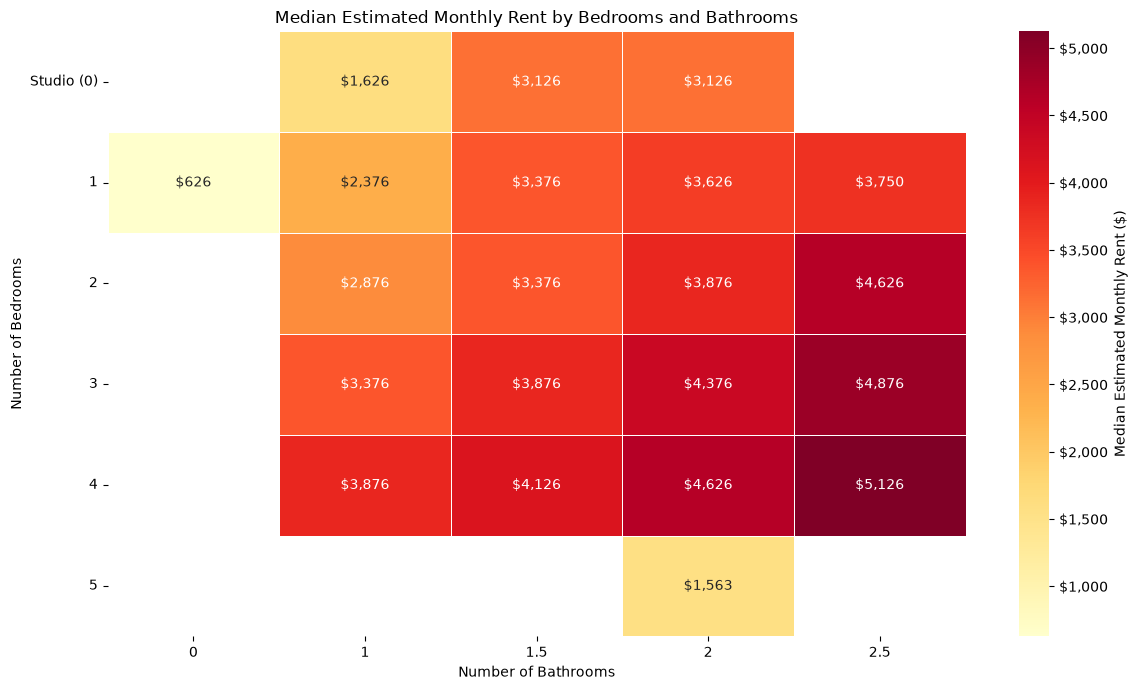

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Keep records with known room counts and estimated rent
usable = sf_rent.dropna(subset=[
    "bedroom_numeric",
    "bathroom_numeric",
    "monthly_rent_midpoint"
])

# Median rent for each bedroom–bathroom combination
rent_heatmap = usable.pivot_table(
    index="bedroom_numeric",
    columns="bathroom_numeric",
    values="monthly_rent_midpoint",
    aggfunc="median"
).sort_index().sort_index(axis=1)

# Convert pandas missing values to plotting-compatible NaN
rent_heatmap = rent_heatmap.astype(float)

# Format cell labels as dollar amounts
annotations = rent_heatmap.apply(
    lambda column: column.map(
        lambda value: f"${value:,.0f}" if pd.notna(value) else ""
    )
)

plt.figure(figsize=(12, 7))

ax = sns.heatmap(
    rent_heatmap,
    annot=annotations,
    fmt="",
    cmap="YlOrRd",
    mask=rent_heatmap.isna(),
    linewidths=0.5,
    cbar_kws={
        "label": "Median Estimated Monthly Rent ($)",
        "format": StrMethodFormatter("${x:,.0f}")
    }
)



ax.set_title("Median Estimated Monthly Rent by Bedrooms and Bathrooms")
ax.set_xlabel("Number of Bathrooms")
ax.set_ylabel("Number of Bedrooms")

ax.set_xticklabels(
    [f"{float(value):g}" for value in rent_heatmap.columns],
    rotation=0
)
ax.set_yticklabels(
    ["Studio (0)" if value == 0 else f"{float(value):g}"
     for value in rent_heatmap.index],
    rotation=0
)

plt.tight_layout()
plt.show()

In [38]:
#median rent by neigbourhood

### 6. Compare Median Rent by Neighborhood and Submission Year

These line charts show how median estimated monthly rent differs across neighborhoods and submission years. Each point is calculated from the usable rent midpoints for one neighborhood in one year.

Include neighborhoods with **more than 100 total submission records across all years combined**. This leaves 37 neighborhoods. Lincoln Park, McLaren Park, Presidio, and Treasure Island are excluded from these plots because their totals are 42, 8, 4, and 3 records, respectively. Their records remain in the dataset. This cutoff is a choice for the charts and does not guarantee that every yearly point has a large number of usable rent records.

Each point label shows the median rent followed by the number of records used to calculate it. For example, **$2,125.50** with **3,139** underneath means the median was calculated from 3,139 usable rent records. The count is not the number of buildings or all apartments in that neighborhood.

All panels use the same rent scale. Compare both the level of rent and how it changes over time. A missing point means there was no usable median for that neighborhood and year; it does not mean the rent was zero. Missing rent and open-ended rent ranges are excluded from the medians. Changes may reflect differences in the apartments reported as well as changes in rent.


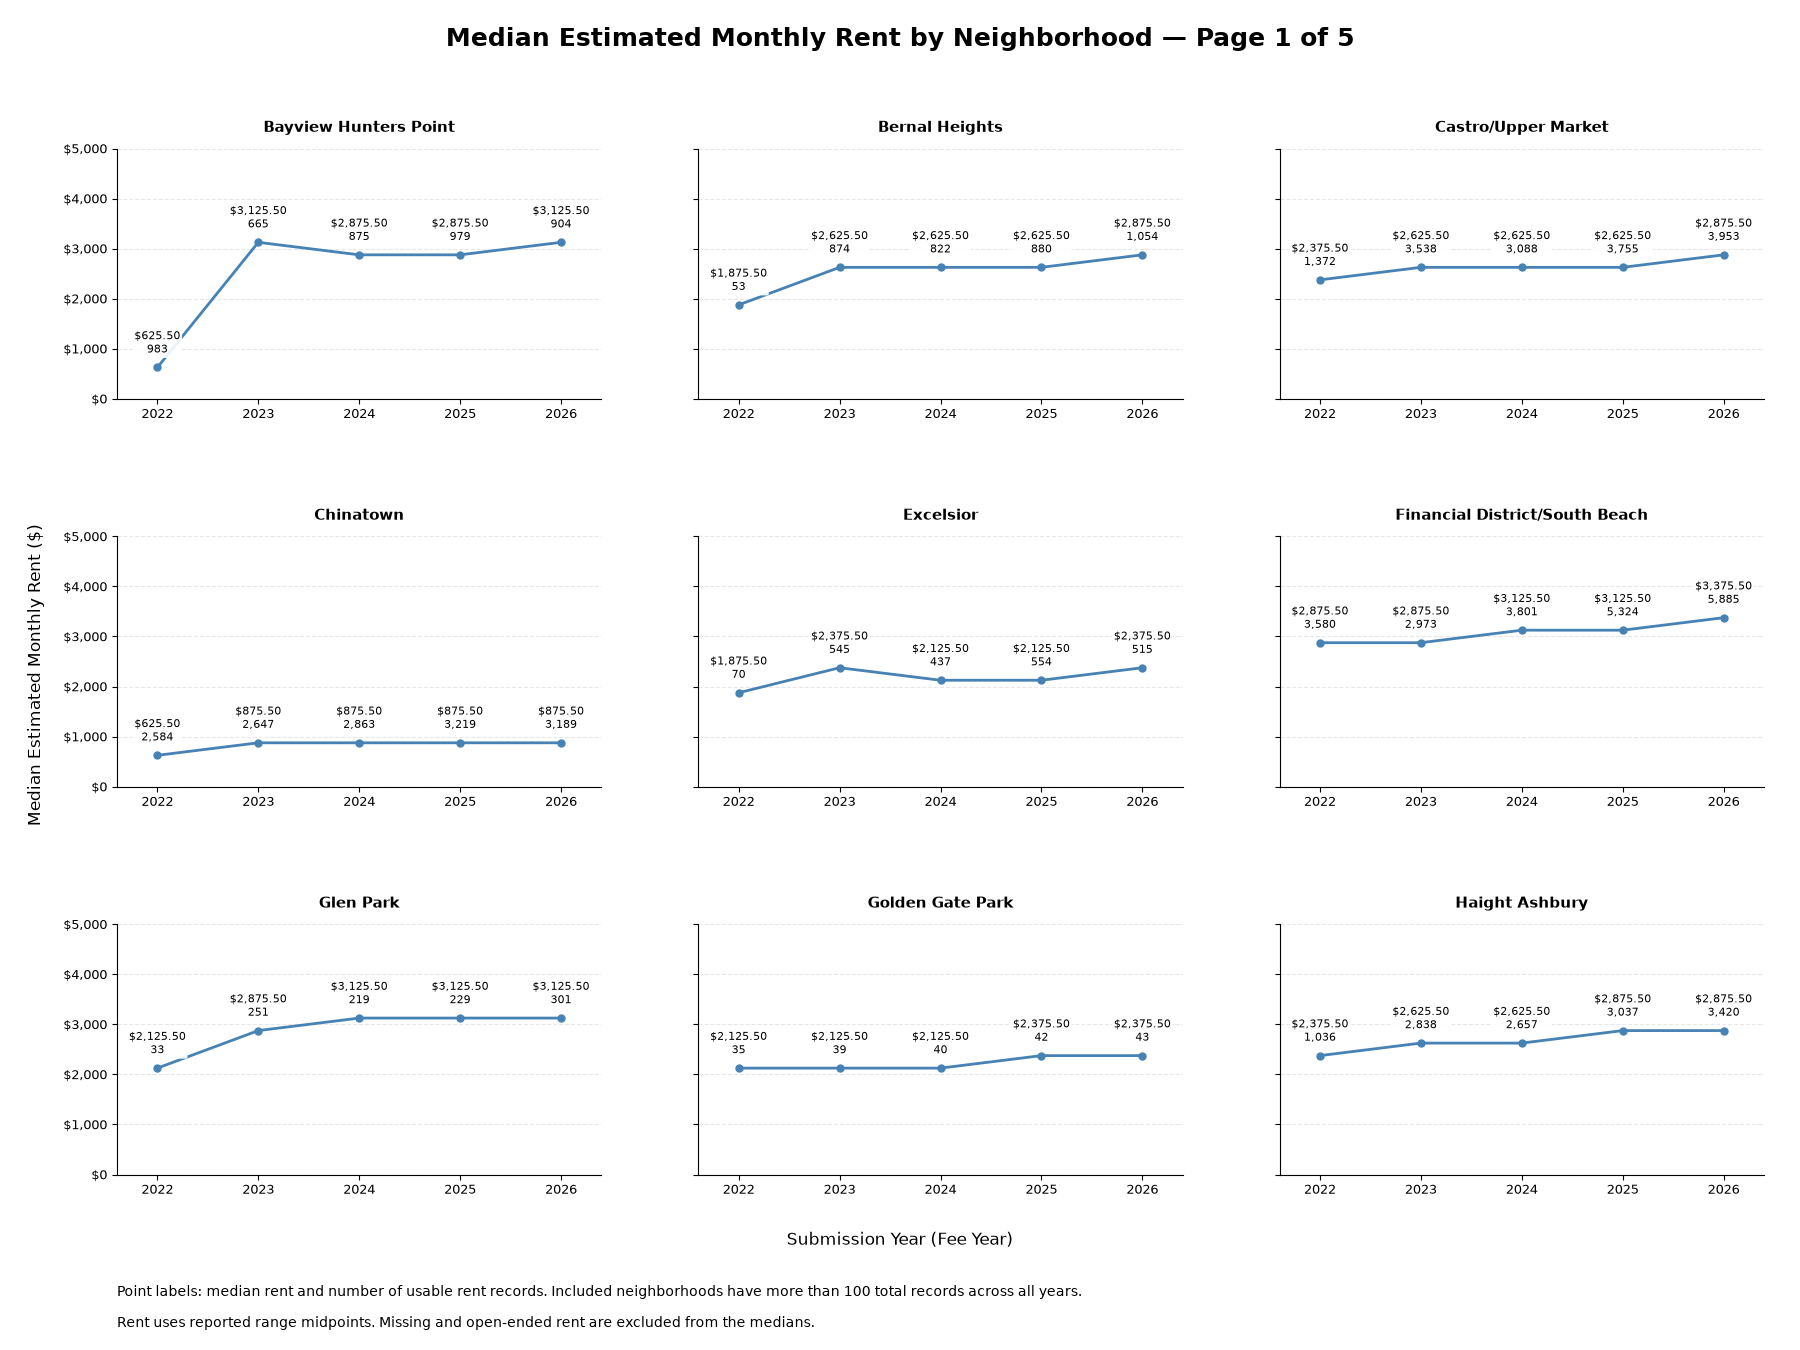

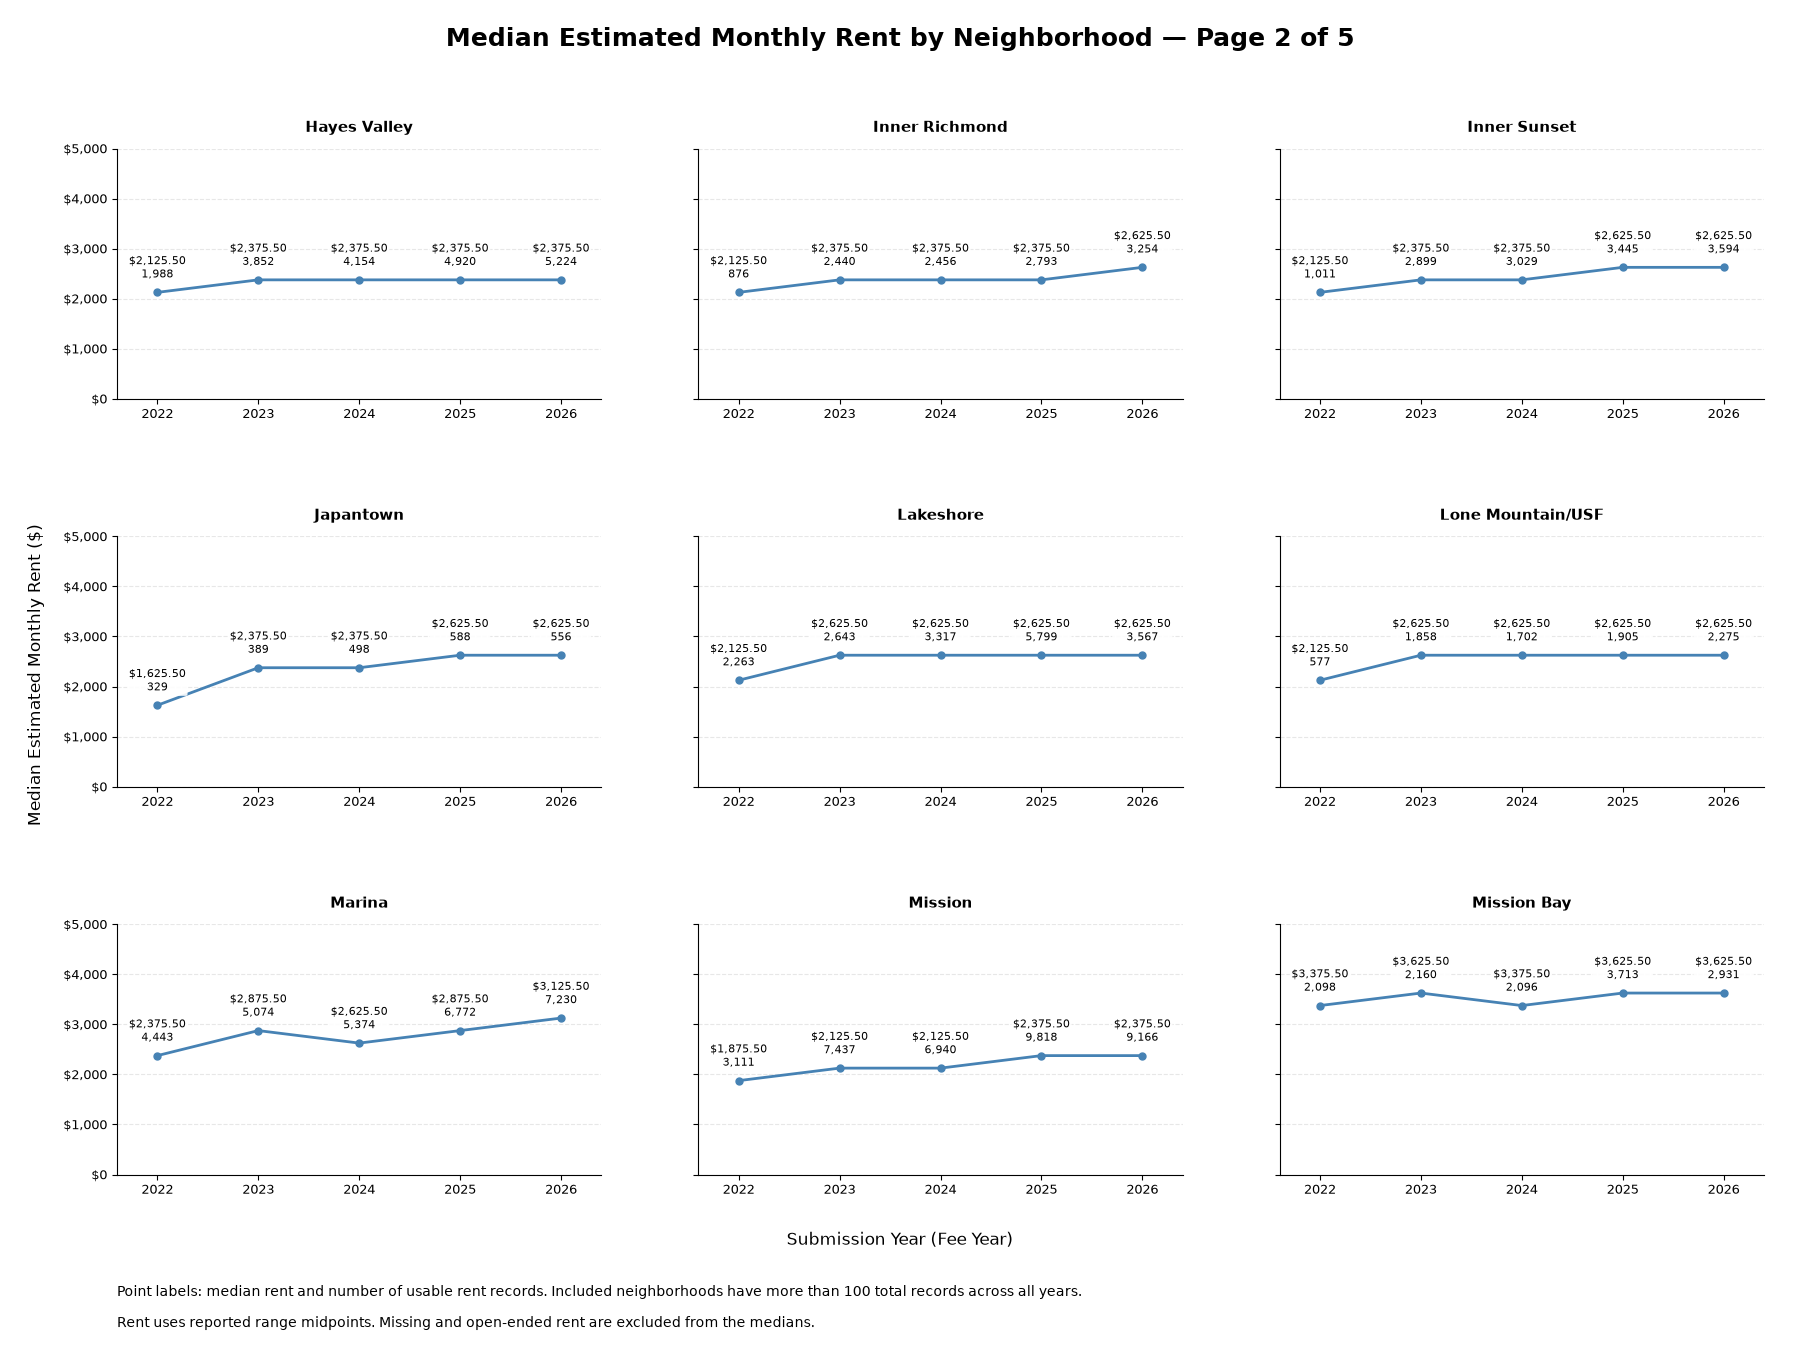

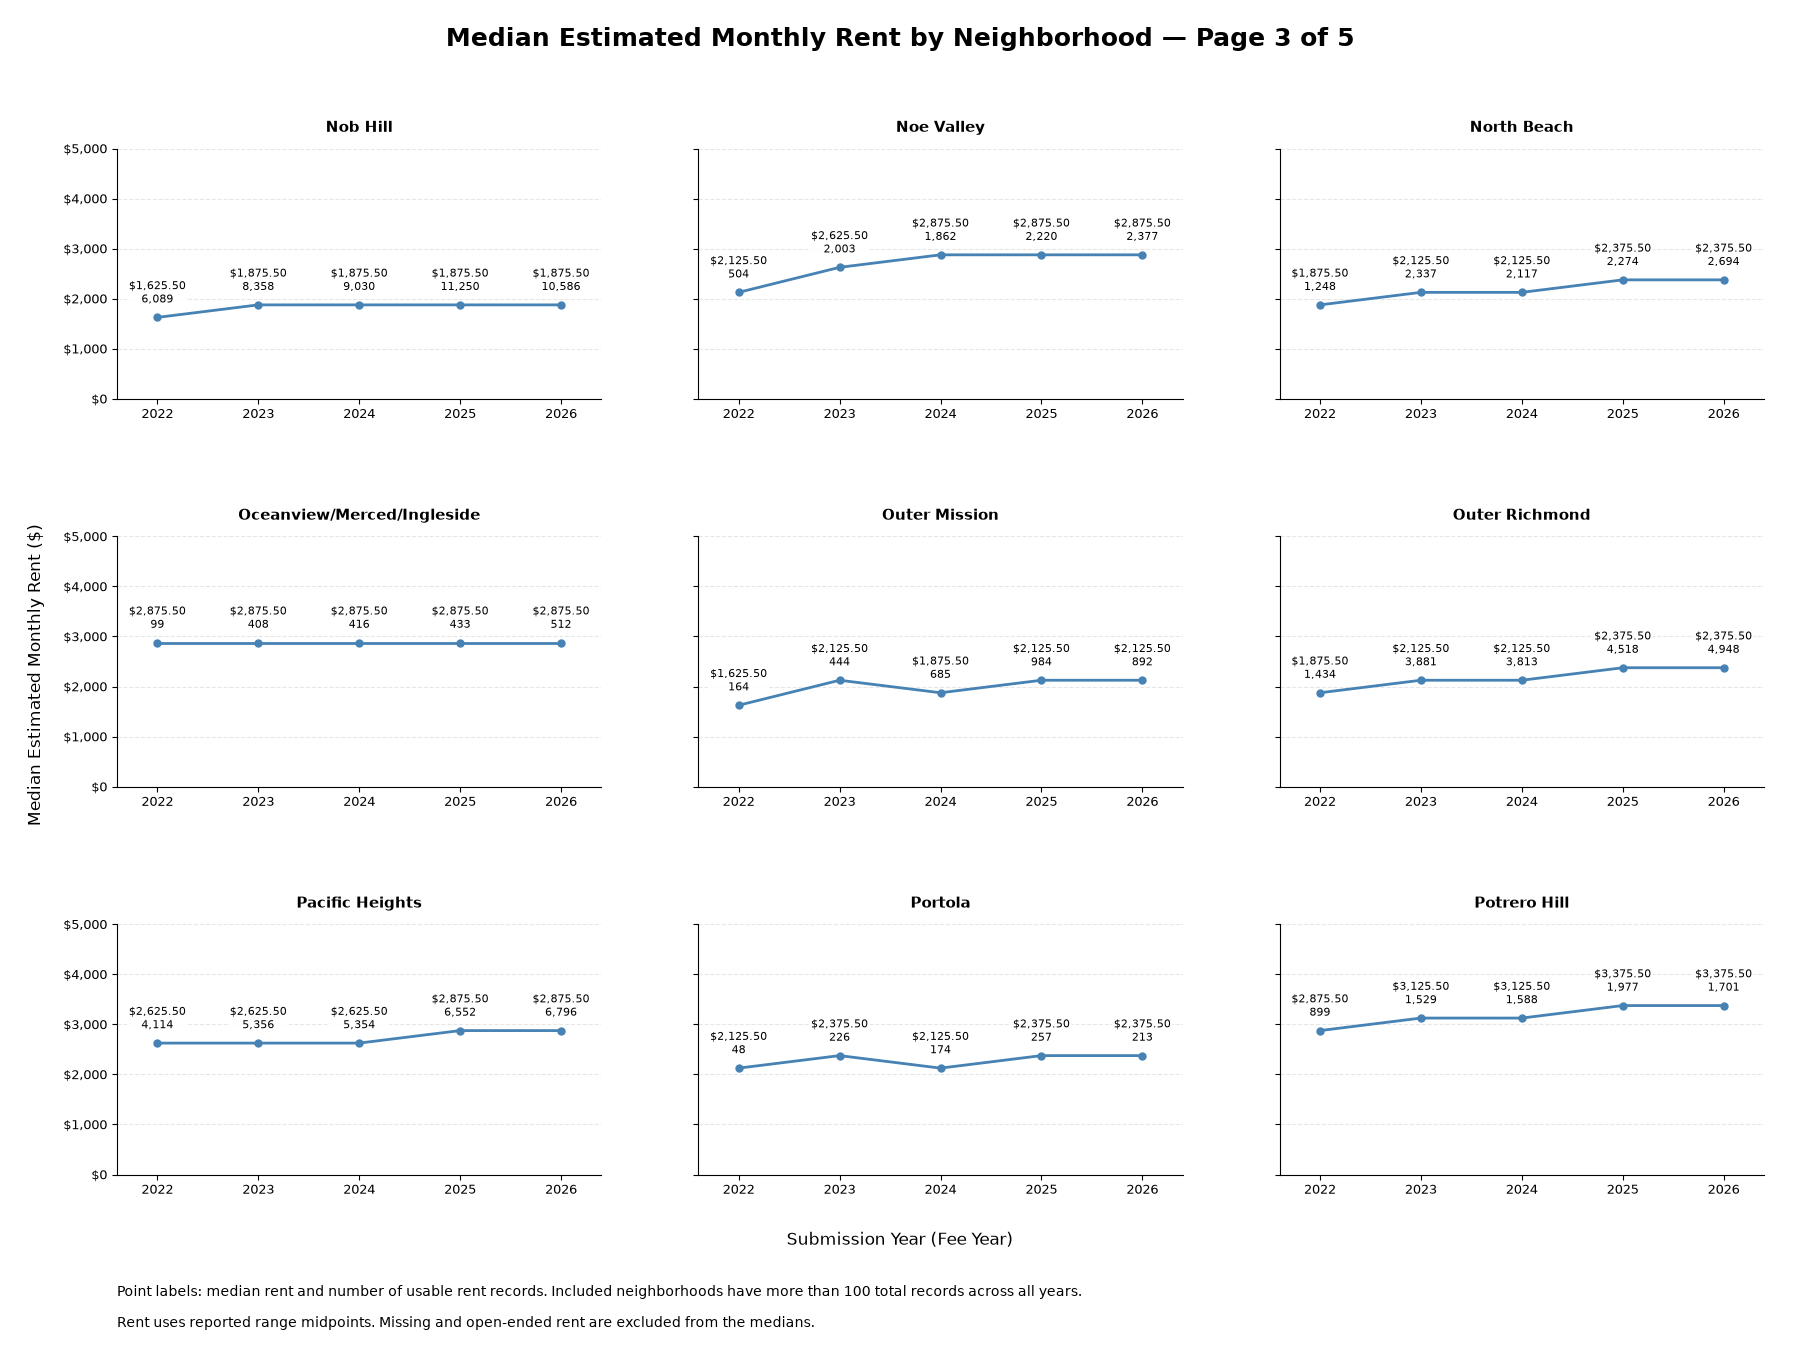

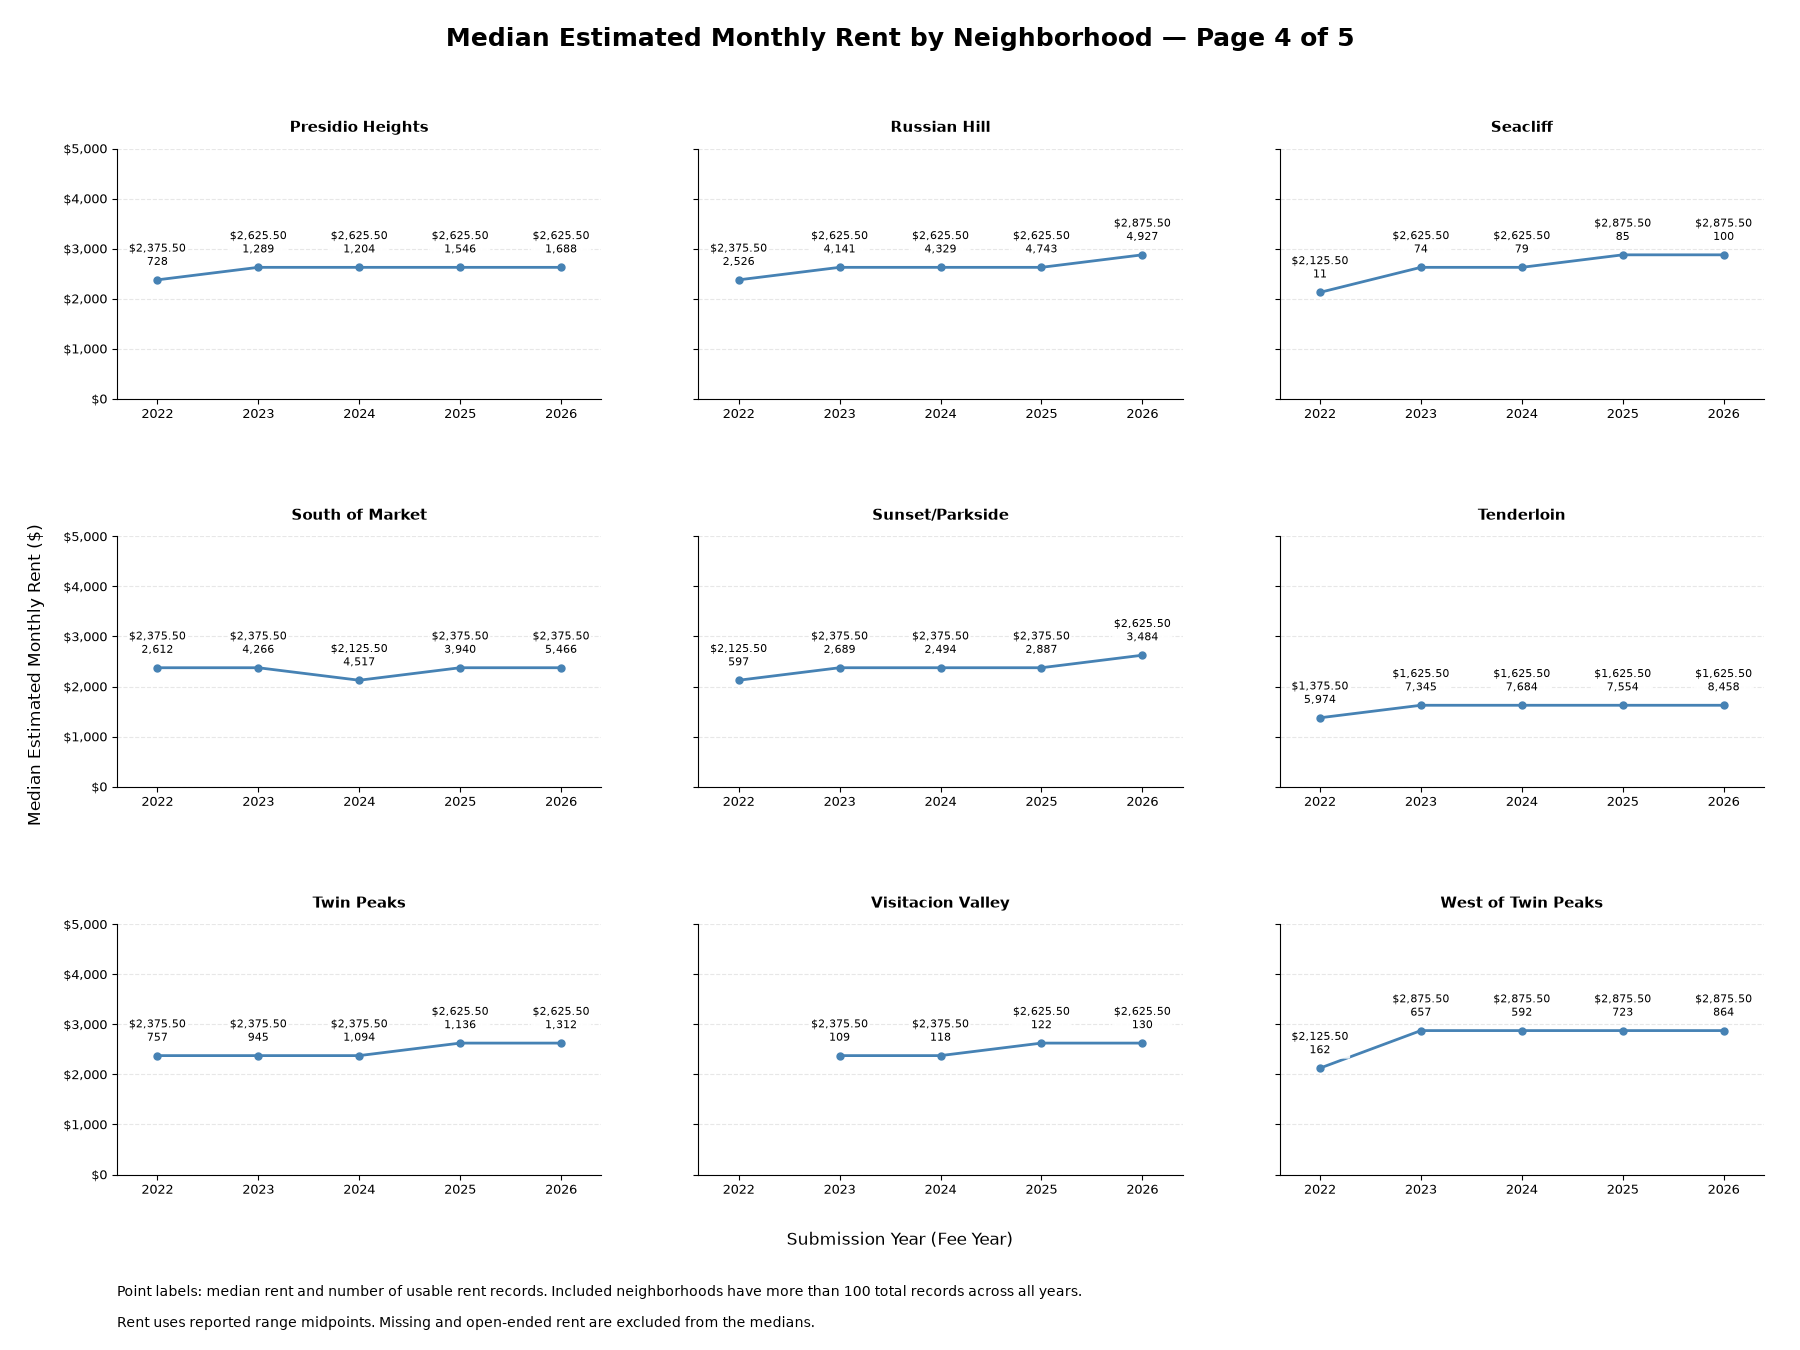

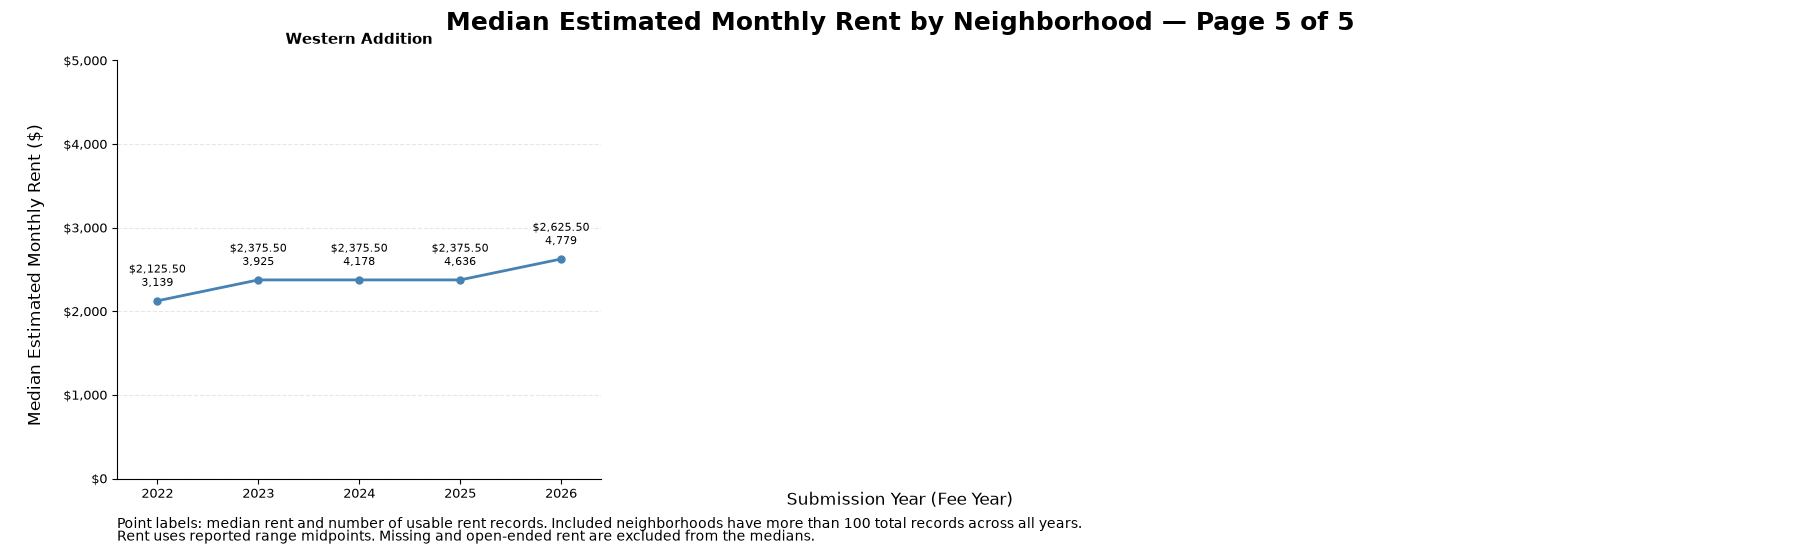

In [ ]:
from matplotlib.ticker import StrMethodFormatter

# Calculate median estimated rent and record counts for each neighborhood and year
rent_by_neigbourhood = sf_rent.groupby(
    ['analysis_neighborhood', 'submission_year']
).agg(
    median_monthly_rent=('monthly_rent_midpoint', 'median'),
    housing_unit_count=('unique_id', 'count'),
    rent_records_used=('monthly_rent_midpoint', 'count')
).reset_index()

# Include neighborhoods with more than 100 total submission records
# The threshold applies across all submission years combined
neighborhood_counts = sf_rent['analysis_neighborhood'].value_counts()
neighborhoods = sorted(
    neighborhood_counts[neighborhood_counts > 100].index
)

rent_by_neigbourhood = rent_by_neigbourhood[
    rent_by_neigbourhood['analysis_neighborhood'].isin(neighborhoods)
]
years = sorted(sf_rent['submission_year'].dropna().unique())
y_max = max(
    1000,
    np.ceil(rent_by_neigbourhood['median_monthly_rent'].max() / 1000) * 1000 + 1000
)

# Show nine neighborhoods per figure so the charts remain readable
total_pages = (len(neighborhoods) + 8) // 9

for page, start in enumerate(range(0, len(neighborhoods), 9), start=1):
    batch = neighborhoods[start:start + 9]
    rows = (len(batch) + 2) // 3

    fig, axes = plt.subplots(
        rows, 3, figsize=(18, rows * 4 + 1.5),
        sharex=True, sharey=True, squeeze=False
    )
    axes = axes.flatten()

    for ind, neighborhood in enumerate(batch):
        ax = axes[ind]
        plot_data = rent_by_neigbourhood[
            rent_by_neigbourhood['analysis_neighborhood'] == neighborhood
        ].set_index('submission_year').reindex(years)

        # Reindexing keeps missing years as gaps rather than joining across them
        ax.plot(
            years, plot_data['median_monthly_rent'],
            marker='o', linewidth=2, markersize=5, color='steelblue'
        )

        for year in years:
            row = plot_data.loc[year]
            if pd.notna(row['median_monthly_rent']):
                ax.annotate(
                    f'${row["median_monthly_rent"]:,.2f}\n'
                    f'{int(row["rent_records_used"]):,}',
                    xy=(year, row['median_monthly_rent']),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.15',
                              facecolor='white', edgecolor='none', alpha=0.9)
                )

        if plot_data['median_monthly_rent'].notna().sum() == 0:
            ax.text(
                0.5, 0.5, 'No usable rent values',
                transform=ax.transAxes, ha='center'
            )

        ax.set_title(neighborhood, fontsize=11, fontweight='bold', pad=12)
        ax.set_xticks(years)
        ax.set_ylim(0, y_max)
        ax.set_xlim(min(years) - 0.4, max(years) + 0.4)
        ax.set_yticks(np.arange(0, y_max + 1, 1000))
        ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
        ax.tick_params(axis='both', labelsize=9, labelbottom=True)
        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='--', alpha=0.30)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide unused panels on the final page
    for ax in axes[len(batch):]:
        ax.set_visible(False)

    fig.suptitle(
        f'Median Estimated Monthly Rent by Neighborhood — Page {page} of {total_pages}',
        fontsize=18, fontweight='bold', y=0.98
    )
    fig.supxlabel('Submission Year (Fee Year)', fontsize=12, y=0.075)
    fig.supylabel('Median Estimated Monthly Rent ($)', fontsize=12, x=0.015)
    fig.text(
        0.065, 0.040,
        'Point labels: median rent and number of usable rent records. '
        'Included neighborhoods have more than 100 total records across all years.',
        fontsize=10
    )
    fig.text(
        0.065, 0.017,
        'Rent uses reported range midpoints. Missing and open-ended rent '
        'are excluded from the medians.',
        fontsize=10
    )
    fig.subplots_adjust(
        left=0.065, right=0.98, bottom=0.13, top=0.89,
        hspace=0.55, wspace=0.20
    )
    plt.show()


In [40]:
sf_rent['analysis_neighborhood'].unique()

<ArrowStringArray>
[                     'Chinatown',                'Sunset/Parkside',
     'Oceanview/Merced/Ingleside',                    'Mission Bay',
                'Pacific Heights',          'Bayview Hunters Point',
 'Financial District/South Beach',                       'Nob Hill',
                     'Noe Valley',                 'Bernal Heights',
                    'North Beach',                   'Hayes Valley',
            'Castro/Upper Market',                        'Mission',
                         'Marina',             'West of Twin Peaks',
                      'Lakeshore',                 'Haight Ashbury',
               'Golden Gate Park',                   'Potrero Hill',
                      'Excelsior',               'Western Addition',
                     'Tenderloin',                 'Outer Richmond',
                  'Outer Mission',               'Presidio Heights',
              'Lone Mountain/USF',                'South of Market',
               

### EDA Findings and Their Limits

The first three charts connect overall occupancy with the bedroom mix and the percentage reported as occupied within each category. They use different denominators, which are explained above each chart. In 2022, approximately 89.2% of studio records were reported as occupied. These percentages include owner-occupied and non-owner-occupied records.

The available records mostly center around one bedroom and one bathroom at the median. Apartments with more bedrooms tend to have more square footage, and apartments with more square footage tend to have higher estimated rent. The yearly median estimated rent rises from $2,125.50 in 2022 to $2,625.50 in 2026.

The neighborhood charts help compare local rent patterns, while the yearly charts help separate those patterns from changes in submission volume. Rent and square footage are based on range midpoints, and missing or open-ended values reduce the records available for these summaries.

These findings describe submitted records. They do not measure rent changes for the same apartment, identify individual buildings, or establish that one feature causes another. Matching a block number and masked block address does not confirm that records belong to the same property.


## Preliminary ML Direction

Based on the EDA, a preliminary ML direction is to predict reported monthly rent using regression, which predicts a numerical value. Rent is positively associated with square footage and bedroom count, while neighborhood charts show differences in median rent. These findings suggest that apartment characteristics and location may help predict rent.

The target would be `monthly_rent_midpoint`, with bedroom and bathroom categories, estimated square footage, neighborhood, and year built as inputs. The initial model would use non-owner-occupied records with known rent midpoints. Linear regression and a tree-based model would be compared with a baseline that predicts the training-set median rent. Performance would be measured using mean absolute error (MAE), the average absolute prediction error in dollars.

Training would use earlier submission years, with later years reserved for evaluation. Rent bounds would be excluded from the inputs because they directly reveal the target. Predictions would represent reported rent-range midpoints, with limitations from missing values, open-ended ranges, and repeated annual submissions.